# MESM calibration --- carbon cycle from 1pctCO2, ECS from abrupt-2xCO2, transient from 1pctCO2

Reproduces `2c_calibrate_MESM.ipynb`'s two-phase calibration (carbon cycle, then
climate sensitivity chained from it), but assigns each MESM DECK experiment to the
quantity it is actually designed to measure:

| component | fitted to | why |
|---|---|---|
| carbon cycle (emis -> conc) | `1pctCO2` | the 1%/yr ramp *defines* the concentration target -- no assumption needed |
| ECS, i.e. $\sum_j q_j$ | `abrupt-2xCO2` equilibrium | a step experiment is the standard ECS diagnostic |
| thermal timescales $d_j$ + partition of $q$ | `1pctCO2` transient | ocean heat uptake under a ramp, which is the regime every application scenario lives in |

**Why not fit the thermal response to abrupt-2xCO2 directly.** MESM's two DECK runs
are *mutually inconsistent under any linear model*, which can be shown without
fitting anything: take MESM's own measured abrupt-2xCO2 step response and linearly
superpose it to predict its 1pctCO2 run. That prediction overshoots MESM's actual
1pctCO2 by **1.50x at TCR** (2.66 K vs 1.78 K at year 70) and by 1.76 K at year 149,
RMSE 1.07 K. Since linear superposition is exactly what *any* impulse-response model
computes, no 3-box (or 300-box) EBM can reproduce both experiments.

The reason is visible in the raw data: MESM's abrupt-2xCO2 run reaches 63% of its
equilibrium in **9 years** and 95% in **49 years**, then is flat for 200 more --
its longest fitted timescale is only 28 years, i.e. essentially no deep-ocean heat
uptake. But 1pctCO2's TCR/ECS = **0.554** requires large *sustained* uptake. That
combination (correct ECS, decadal equilibration) is the signature of a mixed-layer /
Q-flux "slab" ocean configuration, the standard cheap way to measure ECS; the two
runs are also different run series (`1PRCO2` = `25xx.25`, `2CO2` = `31xx.25`).
**This is inferred from the data signature, not from documentation -- worth
confirming with whoever produced the runs.**

Conversely, a 150-year 1pctCO2 ramp *alone* cannot constrain ECS: an unconstrained
3-box fit sends the third box to the integrator limit ($d_3 \to 10^6$ yr,
ECS $\to 10^4$ K) at equally good RMSE. Pinning $\sum_j q_j$ from the 2xCO2
equilibrium removes exactly that degeneracy, which is what
`calibrate_climate_sensitivity(..., sum_q_target=...)` does here.

Checkpoints go to `data/JAX_calibration/calib_MESM_emis_to_conc_both.pkl` and
`calib_MESM_CO2_only_both.pkl` -- separate files, nothing existing is overwritten.
Part 2 assesses **extrapolative skill**: the resulting parameters are pushed forward
onto Tier 1 / Tier 2 / CS3 / DECK and scored against MESM's own zonal output,
side by side with the existing `MESM_PARAMS` baseline.

In [1]:
import glob
import pickle
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jax.numpy as jnp

import utils_FaIR_JAX
import utils_inverse
import utils_plotting
from paths import DATA_DIR

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

## Part 1: Calibration

### Phase 1: Calibrate carbon cycle via emissions -> concentrations (1pctCO2)

In [2]:
# Load MESM's 1pctCO2 emissions-driven ensemble (real prescribed emissions, used
# to calibrate the carbon cycle below) and the 2xCO2 implied emissions (diagnosed
# by MESM's own carbon cycle as consistent with the abrupt CO2-doubling
# concentration path -- MESM is concentration-driven for this experiment, so
# there's no directly prescribed emissions series the way there is for 1pctCO2).
# `emis_mat_2xco2` isn't used for calibration (Phase 2 prescribes concentration
# directly, bypassing the carbon cycle) -- it's kept for Phase 3's verification,
# which checks the fully-chained model against *both* experiments' real emissions.
emis_path = str(DATA_DIR / 'MESM' / 'emis_driven')

emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'
emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = jnp.zeros((5, len(emis_1pct)))
emis_mat_1pct = emis_mat_1pct.at[0,:].set(emis_1pct)

emis_2xco2_path = f'{emis_path}/2xCO2/implco2emiss.3100.25.txt'
emis_2xco2 = np.loadtxt(emis_2xco2_path, usecols=(2,))
emis_mat_2xco2 = jnp.zeros((5, len(emis_2xco2)))
emis_mat_2xco2 = emis_mat_2xco2.at[0,:].set(emis_2xco2)

# Phase 1's calibration input: 1pctCO2 only.
emis_dict_1pct = {'1pctCO2': emis_mat_1pct}
# Phase 3's verification input: both experiments' real emissions.
emis_dict = {'1pctCO2': emis_mat_1pct, '2xCO2': emis_mat_2xco2}

In [3]:
# Target CO2 concentration curve for the carbon-cycle fit: 1pctCO2 ramps at 1%/yr
# by definition, from MESM's 286.4 ppm preindustrial baseline
# (utils_FaIR_JAX.MESM_PARAMS['C0_PI']).
base_co2 = 286.4

co2_1pct = base_co2 * (1.01 ** np.arange(len(emis_1pct)))
conc_mat_1pct_carbon = jnp.zeros((3, len(co2_1pct)))
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[0,:].set(co2_1pct)
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[1,:].set(720.0)
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[2,:].set(270.0)

target_conc_dict_1pct = {'1pctCO2': conc_mat_1pct_carbon}

In [4]:
CARBON_FILEPATH = 'data/JAX_calibration/calib_MESM_emis_to_conc_both.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')

# Single-scenario fit (1pctCO2 only), so this matches scripts/2c_calibrate_MESM.py's
# original hyperparameters exactly (lr=1e-2, n_steps=200) -- no cross-scenario
# loss-balancing needed here, unlike a joint multi-experiment fit.
theta_opt_emis, _ = utils_FaIR_JAX.calibrate_carbon_cycle(
    CARBON_FILEPATH, emis_dict_1pct, target_conc_dict_1pct, theta0, dt=0.1, n_steps=200,
    learning_rate=1e-2, mode='FaIR', base_params=utils_FaIR_JAX.MESM_PARAMS,
)

Starting Carbon Cycle Calibration (Emis -> Conc)...


Step 0 | Loss (Conc MSE): 287.6098


Step 100 | Loss (Conc MSE): 25.8132


Step 199 | Loss (Conc MSE): 16.3085


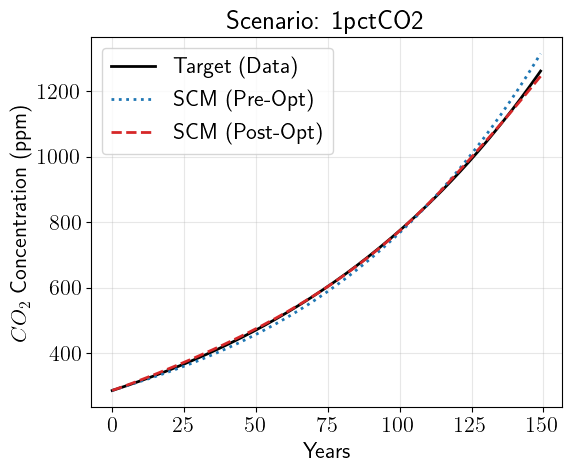

In [5]:
utils_plotting.plot_calibration_results(
    None, emis_dict_1pct, target_conc_dict_1pct, theta0, theta_opt_emis, dt=0.1,
    calib='Carbon', base_params=utils_FaIR_JAX.MESM_PARAMS,
)

### Phase 2a: Energy balance from the DECK experiments alone --- ECS pinned from abrupt-2xCO2, timescales from the 1pctCO2 transient

In [4]:
# MESM's concentration-driven ensemble output (target GMST). avg_1pct is used
# only by Phase 3's verification below; avg_2xco2 is Phase 2's own calibration
# target -- the abrupt-2xCO2 GMST response is what actually constrains the
# energy-balance (d, q) parameters here.
conc_path = str(DATA_DIR / 'MESM' / 'conc_driven')

def calculate_ensemble_average(file_pattern):
    # Find all files matching the string pattern (e.g., 'dt2m_ascii_*.txt')
    file_list = glob.glob(file_pattern)

    if not file_list:
        print("No files found matching the pattern.")
        return None

    all_data = []
    for file in file_list:
        # usecols=(1,) extracts the GMST anomaly column
        data = np.loadtxt(file, usecols=(1,))
        all_data.append(data)

    ensemble_stack = np.stack(all_data)
    return np.mean(ensemble_stack, axis=0)

avg_1pct = calculate_ensemble_average(f'{conc_path}/1PRCO2/dt2m_ascii_*.txt')
avg_2xco2 = calculate_ensemble_average(f'{conc_path}/2CO2/dt2m_ascii_*.txt')

In [5]:
# ECS measured from the abrupt-2xCO2 run's own equilibrium (flat to within
# ensemble noise over the last 50 of its 250 years). This is the one number that
# experiment constrains well, and the one a 150-year ramp cannot constrain at all.
mesm_ecs = float(np.mean(avg_2xco2[-50:]))

# ECS = F_2xCO2 * sum(q), and F_2xCO2 is fixed by the RF formula (not calibrated --
# it is exactly degenerate with sum(q) for GMST-only targets, so fitting both would
# be unidentifiable). Inverting gives the sum(q) the thermal fit must respect.
F2x = float(utils_FaIR_JAX.radiative_forcing_co2(2 * base_co2, utils_FaIR_JAX.MESM_PARAMS))
sum_q_target = mesm_ecs / F2x

print(f"MESM abrupt-2xCO2 equilibrium (ECS) = {mesm_ecs:.3f} K")
print(f"F_2xCO2 (fixed by RF formula)       = {F2x:.4f} W/m2")
print(f"=> pinned sum(q)                    = {sum_q_target:.4f} K/(W/m2)")
print(f"MESM 1pctCO2 TCR (yr 70, 2x crossing) = {avg_1pct[70]:.3f} K"
      f"  -> TCR/ECS = {avg_1pct[70]/mesm_ecs:.3f}")

MESM abrupt-2xCO2 equilibrium (ECS) = 3.205 K
F_2xCO2 (fixed by RF formula)       = 3.7748 W/m2
=> pinned sum(q)                    = 0.8490 K/(W/m2)
MESM 1pctCO2 TCR (yr 70, 2x crossing) = 1.775 K  -> TCR/ECS = 0.554


In [6]:
# Prescribed CO2 concentration paths. 1pctCO2 (the 1%/yr ramp) is Phase 2's fit
# target; 2xCO2 (an abrupt step to 2x baseline, held flat) is built here too but is
# *held out* of the fit -- it only supplied the ECS scalar above, so its trajectory
# is an independent check plotted below.
n_years_1pct = len(avg_1pct)
n_years_2xco2 = len(avg_2xco2)

co2_1pct = base_co2 * (1.01 ** np.arange(n_years_1pct))
conc_mat_1pct = jnp.zeros((3, n_years_1pct))
conc_mat_1pct = conc_mat_1pct.at[0,:].set(co2_1pct)
conc_mat_1pct = conc_mat_1pct.at[1,:].set(720.0)
conc_mat_1pct = conc_mat_1pct.at[2,:].set(270.0)

co2_2xco2 = jnp.full(n_years_2xco2, 2 * base_co2)
conc_mat_2xco2 = jnp.zeros((3, n_years_2xco2))
conc_mat_2xco2 = conc_mat_2xco2.at[0,:].set(co2_2xco2)
conc_mat_2xco2 = conc_mat_2xco2.at[1,:].set(720.0)
conc_mat_2xco2 = conc_mat_2xco2.at[2,:].set(270.0)

# Phase 2's fit: 1pctCO2 only.
conc_dict_fit   = {'1pctCO2': conc_mat_1pct}
target_dict_fit = {'1pctCO2': avg_1pct}
# Concentration-prescribed calibration bypasses the carbon cycle; this all-zero
# array only supplies the aerosol/BC terms, which are zero for CO2-only DECK runs.
emis_dict_climate_fit = {'1pctCO2': jnp.zeros((5, n_years_1pct))}

# Both experiments, for the diagnostic plot (2xCO2 = held out).
conc_dict_both   = {'1pctCO2': conc_mat_1pct, '2xCO2': conc_mat_2xco2}
target_dict_both = {'1pctCO2': avg_1pct, '2xCO2': avg_2xco2}
emis_dict_climate_both = {'1pctCO2': jnp.zeros((5, n_years_1pct)),
                          '2xCO2': jnp.zeros((5, n_years_2xco2))}

In [9]:
CLIMATE_FILEPATH = 'data/JAX_calibration/calib_MESM_CO2_only_both.pkl'

# Chained from Phase 1's carbon-cycle theta_opt_emis (only the Climate-masked d/q
# entries move from here). sum_q_target pins ECS to the abrupt-2xCO2 value, so the
# 1000 steps below determine only the thermal timescales d and how q is partitioned
# across the three boxes -- removing the ramp-only degeneracy described at the top.
theta_opt, _ = utils_FaIR_JAX.calibrate_climate_sensitivity(
    CLIMATE_FILEPATH, emis_dict_climate_fit, conc_dict_fit, target_dict_fit, theta_opt_emis,
    dt=0.1, n_steps=1000, learning_rate=1e-2, base_params=utils_FaIR_JAX.MESM_PARAMS,
    sum_q_target=sum_q_target,
)

_pf = utils_FaIR_JAX.params_from_theta(theta_opt, utils_FaIR_JAX.MESM_PARAMS)
_o = np.argsort(np.asarray(_pf['d']))
print(f"\n  fitted d (yr) = {np.round(np.asarray(_pf['d'])[_o], 2)}")
print(f"  fitted q      = {np.round(np.asarray(_pf['q'])[_o], 4)}  (sum={float(jnp.sum(_pf['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pf['q'])):.2f} K (pinned to MESM's {mesm_ecs:.2f} K)")

Starting Climate Sensitivity Calibration (Conc -> Temp)...


Step 0 | Loss (Temp MSE): 0.0868
Step 100 | Loss (Temp MSE): 0.0018
Step 200 | Loss (Temp MSE): 0.0015
Step 300 | Loss (Temp MSE): 0.0014


Step 400 | Loss (Temp MSE): 0.0013
Step 500 | Loss (Temp MSE): 0.0012
Step 600 | Loss (Temp MSE): 0.0011
Step 700 | Loss (Temp MSE): 0.0010


Step 800 | Loss (Temp MSE): 0.0010
Step 900 | Loss (Temp MSE): 0.0009
Step 999 | Loss (Temp MSE): 0.0008

  fitted d (yr) = [  0.7   17.43 179.65]
  fitted q      = [0.2123 0.269  0.3677]  (sum=0.8490)
  => ECS = 3.20 K (pinned to MESM's 3.20 K)


Left panel is the fitted experiment (1pctCO2). Right panel, `2xCO2`, is **held out** ---
only its equilibrium value entered the fit, not its trajectory --- so the gap there is
the inconsistency documented at the top of this notebook, not a fitting failure.

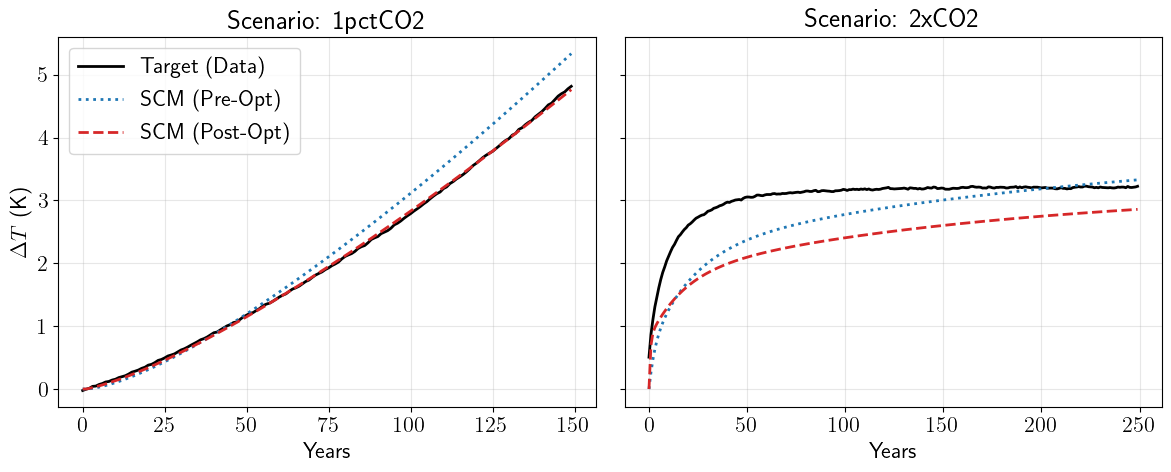

In [10]:
utils_plotting.plot_calibration_results(
    conc_dict_both, emis_dict_climate_both, target_dict_both, theta_opt_emis, theta_opt, dt=0.1,
    base_params=utils_FaIR_JAX.MESM_PARAMS,
)

### Phase 2b: add the Tier 1 scenarios to the *timescale* fit

Tier 1's runs are real multi-century transients, so they constrain the long thermal timescale that a 150-year ramp cannot see and that the fast-equilibrating 2xCO2 run actively argues against. ECS stays pinned from abrupt-2xCO2 --- Tier 1 informs $d_j$ and the partition of $q$ only, never $\sum_j q_j$.

**This makes Tier 1 in-sample.** The honest held-out set for Part 2 is therefore Tier 2, CS3, and 2xCO2's trajectory.

In [11]:
# Tier 1 gives the thermal fit something neither DECK experiment can: real
# multi-century transients (H-ext and VLLO-ext run 477 years) that actually
# exercise the post-peak, declining-emissions regime where Phase 2a's fit was
# weakest. ECS stays pinned from abrupt-2xCO2 -- Tier 1 enters the *timescale*
# side of the fit only, never the ECS side.
#
# Reuses scripts/2d_calibrate_MESM_alt.py's build_tier1_dataset verbatim: it
# already handles the two alignment subtleties this needs, namely
# build_dataset_vector_targets's target_crop_future=162 crop for the future
# scenarios and the EMIS_OFFSET_HIST=111 offset for `historical` (MESM's own
# historical run starts at calendar 1861, not 1750 -- a gap in 6d's own
# SCM-direct comparison, documented in that script).
import jax
import optax

PROJECT_ROOT = Path.cwd()
_spec2d = importlib.util.spec_from_file_location(
    "s2d_alt", PROJECT_ROOT / "scripts" / "2d_calibrate_MESM_alt.py")
s2d = importlib.util.module_from_spec(_spec2d)
_spec2d.loader.exec_module(s2d)

AGENTS_T1 = ("CO2",)
tier1_emis, tier1_truth = s2d.build_tier1_dataset()

# Training set: all seven Tier 1 scenarios + 1pctCO2. 2xCO2's *trajectory* is
# deliberately excluded -- only its equilibrium enters, through sum_q_target.
TRAIN_T1 = s2d.TIER1_SCORED_SCENARIOS + ["1pctCO2"]

yrs_h_t1, emis_h_t1 = utils_inverse.extract_years_and_emis(
    tier1_emis["historical"], agents=AGENTS_T1)
per_scen_t1 = {}
for s in s2d.TIER1_FUTURE_SCENARIOS:      # every one of these is in scens_with_hist
    y, e = utils_inverse.extract_years_and_emis(tier1_emis[s], agents=AGENTS_T1)
    per_scen_t1[s] = dict(years_curr=y, emis_curr_dict=e,
                          years_hist=yrs_h_t1, emis_hist_dict=emis_h_t1)
per_scen_t1["historical"] = dict(years_curr=yrs_h_t1, emis_curr_dict=emis_h_t1,
                                 years_hist=None, emis_hist_dict=None)
y, e = utils_inverse.extract_years_and_emis(tier1_emis["1pctCO2"], agents=AGENTS_T1)
per_scen_t1["1pctCO2"] = dict(years_curr=y, emis_curr_dict=e,
                              years_hist=None, emis_hist_dict=None)
hist_len_t1 = int(tier1_truth["historical"].shape[0])
print("training scenarios:", TRAIN_T1)

training scenarios: ['H-ext', 'M', 'ML', 'L', 'VLHO', 'VLLO-ext', 'historical', '1pctCO2']


In [12]:
def _project_sumq(th, target):
    """Same ECS constraint as Phase 2a, applied inside this fit's own loss."""
    q = jnp.exp(th[8:11])
    q = q * (target / jnp.sum(q))
    return th.at[8:11].set(jnp.log(q))

def _scen_nrmse_t1(th, scen):
    """Per-scenario NRMSE through the FULL emissions -> temperature pipeline.
    Unlike Phase 2a's prescribed-concentration fit there is no concentration
    ground truth for Tier 1 (data/MESM/conc_driven/ holds only 1PRCO2 and 2CO2),
    so concentration is simulated by Phase 1's carbon cycle, which stays frozen
    here (Climate-only mask). Caveat that buys: any carbon-cycle bias on these
    scenarios can be partly absorbed into the thermal parameters."""
    params = utils_FaIR_JAX.params_from_theta(
        _project_sumq(th, sum_q_target), base_params=utils_FaIR_JAX.MESM_PARAMS)
    # NOTE: deliberately does NOT pass agents=("CO2",) here. Doing so builds a
    # 1-row emissions array, and simulate_temp then reads rows idx_CH4=1 ..
    # idx_BC=4, which are out of bounds and which JAX silently CLAMPS to row 0 --
    # injecting the CO2 series as CH4, N2O, sulfur and BC emissions at once
    # (verified: 0.65 K max error on 'M'). Leaving agents at its default
    # AGENTS_DEFAULT makes simulate_targets_gmst zero-fill the four absent
    # agents properly, which is what scripts/6d_scm_mesm_fidelity.py does and
    # what makes this loss consistent with Part 2's scoring.
    # scripts/2d_calibrate_MESM_alt.py's run_tier1_joint DOES pass agents=("CO2",)
    # and so is affected by this -- reported, not silently patched here.
    pred = utils_inverse.simulate_targets_gmst(
        mode="MESM", dt=0.1, params=params, use_checkpoint=True,
        **per_scen_t1[scen])
    if scen == "historical":
        pred = pred[s2d.EMIS_OFFSET_HIST:s2d.EMIS_OFFSET_HIST + hist_len_t1]
    true = tier1_truth[scen]
    n = min(pred.shape[0], true.shape[0])
    return utils_FaIR_JAX.calc_nrmse(pred[:n], true[:n]), n

# One value_and_grad per scenario rather than one over all of them: identical
# descent direction (the gradient of a length-weighted mean is the weighted mean
# of the gradients), but bounded peak compile memory -- 2d_calibrate_MESM_alt.py
# documents a deterministic OOM from tracing every scenario's lax.scan at once.
# NOT jittable: simulate_targets_gmst -> _make_contiguous_years branches on a
# traced value (utils_inverse.py:203).
vg_t1 = {s: jax.value_and_grad(lambda th, ss=s: _scen_nrmse_t1(th, ss)[0]) for s in TRAIN_T1}
lens_t1 = jnp.asarray([_scen_nrmse_t1(theta_opt_emis, s)[1] for s in TRAIN_T1], dtype=jnp.float32)
w_t1 = lens_t1 / jnp.sum(lens_t1)   # length-weighted (spans 127-477 yr), per 2d's convention

N_STEPS_T1 = 300
opt = optax.adam(learning_rate=1e-2)
theta_t1 = theta_opt_emis                       # chained from Phase 1's carbon cycle
opt_state = opt.init(theta_t1)
mask_clim = utils_FaIR_JAX.make_theta_mask(theta_t1, target="Climate")

print(f"Tier1-augmented timescale fit: {len(TRAIN_T1)} scenarios, {N_STEPS_T1} steps "
      f"(~2.4 s/step) ...")
for step in range(N_STEPS_T1):
    ls, gs = [], []
    for s in TRAIN_T1:
        l, g = vg_t1[s](theta_t1)
        ls.append(l); gs.append(g)
    loss = jnp.sum(jnp.stack(ls) * w_t1)
    grad = jnp.sum(jnp.stack(gs) * w_t1[:, None], axis=0) * mask_clim
    updates, opt_state = opt.update(grad, opt_state, theta_t1)
    theta_t1 = optax.apply_updates(theta_t1, updates)
    # Re-tracing this un-jittable loss leaks ~78 MB/step (measured: 0.95 -> 3.70 GB
    # over 35 steps); clearing every 10 steps holds it flat at ~1.7 GB.
    if (step + 1) % 10 == 0:
        jax.clear_caches()
    if step % 25 == 0 or step == N_STEPS_T1 - 1:
        print(f"  step {step:3d} | length-weighted mean NRMSE: {float(loss):.4f}", flush=True)

theta_opt_t1 = _project_sumq(theta_t1, sum_q_target)

_pt = utils_FaIR_JAX.params_from_theta(theta_opt_t1, utils_FaIR_JAX.MESM_PARAMS)
_ot = np.argsort(np.asarray(_pt['d']))
print(f"\n  Phase 2b d (yr) = {np.round(np.asarray(_pt['d'])[_ot], 2)}")
print(f"  Phase 2b q      = {np.round(np.asarray(_pt['q'])[_ot], 4)}  (sum={float(jnp.sum(_pt['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pt['q'])):.2f} K (still pinned to MESM's {mesm_ecs:.2f} K)")

# Persist the adopted calibration. Phase 2b's manual optax loop (unlike
# calibrate_carbon_cycle / calibrate_climate_sensitivity) has no built-in
# checkpointing, so without this the best parameter set in this notebook would
# exist only in kernel memory. This is the file downstream work should load:
# carbon cycle from 1pctCO2 (Phase 1), ECS pinned from abrupt-2xCO2, thermal
# timescales from 1pctCO2 + all seven Tier 1 scenarios (Phase 2b).
TIER1_FILEPATH = 'data/JAX_calibration/calib_MESM_tier1_augmented.pkl'
with open(TIER1_FILEPATH, 'wb') as f:
    pickle.dump(theta_opt_t1, f)
print(f"\n  adopted calibration saved -> {TIER1_FILEPATH}")

Tier1-augmented timescale fit: 8 scenarios, 300 steps (~2.4 s/step) ...


  step   0 | length-weighted mean NRMSE: 0.1463


  step  25 | length-weighted mean NRMSE: 0.1152


  step  50 | length-weighted mean NRMSE: 0.1072


  step  75 | length-weighted mean NRMSE: 0.1032


...

  step 225 | length-weighted mean NRMSE: 0.0954


  step 250 | length-weighted mean NRMSE: 0.0948


  step 275 | length-weighted mean NRMSE: 0.0945


  step 299 | length-weighted mean NRMSE: 0.0943



  Phase 2b d (yr) = [ 0.53 70.1  89.46]
  Phase 2b q      = [0.2417 0.292  0.3153]  (sum=0.8490)
  => ECS = 3.20 K (still pinned to MESM's 3.20 K)

  adopted calibration saved -> data/JAX_calibration/calib_MESM_tier1_augmented.pkl


### Phase 3: emissions to temperature (verification)

Phase 2a (DECK-only timescales):


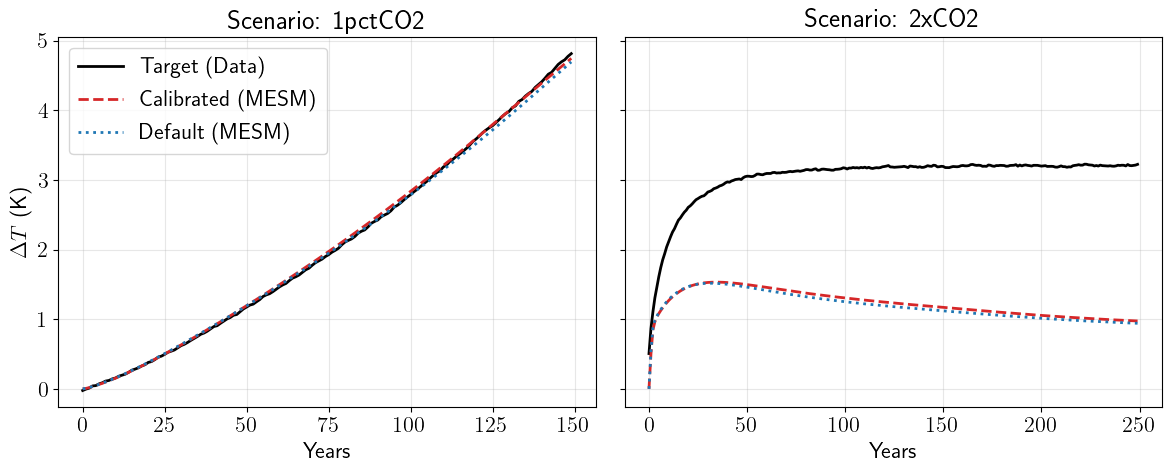

Phase 2b (Tier1-augmented timescales):


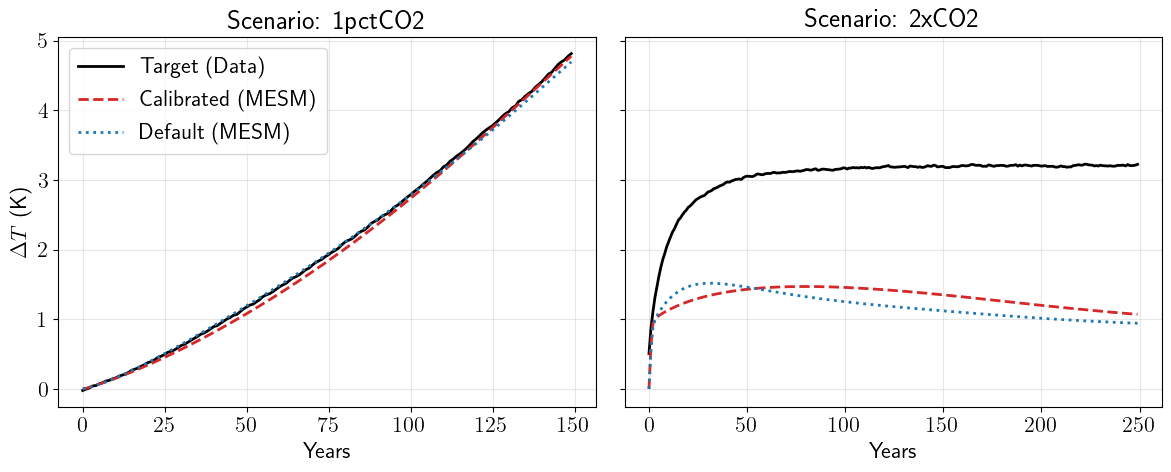

In [13]:
# Full emissions -> temperature pipeline on both DECK experiments, for the
# Phase 2a (DECK-only) and Phase 2b (Tier1-augmented) thermal fits.
target_dict_verify = {'1pctCO2': avg_1pct, '2xCO2': avg_2xco2}
print("Phase 2a (DECK-only timescales):")
utils_plotting.plot_model_comparison(emis_dict, target_dict_verify, theta_opt, mode='MESM', dt=0.1)
print("Phase 2b (Tier1-augmented timescales):")
utils_plotting.plot_model_comparison(emis_dict, target_dict_verify, theta_opt_t1, mode='MESM', dt=0.1)

## Part 2: Extrapolative skill

Three parameter sets are pushed forward onto every eval scenario and scored against
MESM's own zonal output, reusing `scripts/6d_scm_mesm_fidelity.py`'s eval-set
construction, ground truth and `nrmse_r2` unmodified:

| label | carbon cycle | ECS | thermal timescales |
|---|---|---|---|
| `baseline` | existing `MESM_PARAMS` (original 1pctCO2-only calibration) | | |
| `deck` | 1pctCO2 | abrupt-2xCO2 | 1pctCO2 only (Phase 2a) |
| `tier1` | 1pctCO2 | abrupt-2xCO2 | 1pctCO2 **+ Tier 1** (Phase 2b) |

**In-sample / held-out is now different for each column**, and the table below
labels it per row. For `tier1`, Tier 1 and 1pctCO2 are training data; the honest
out-of-sample test is **Tier 2, CS3 and 2xCO2's trajectory**. For `baseline` and
`deck`, everything outside DECK is out of sample.

In [8]:
params_split = utils_FaIR_JAX.params_from_theta(theta_opt, utils_FaIR_JAX.MESM_PARAMS)
params_tier1 = utils_FaIR_JAX.params_from_theta(theta_opt_t1, utils_FaIR_JAX.MESM_PARAMS)

# scripts/6d_scm_mesm_fidelity.py's name starts with a digit, so it can't be
# imported with a normal `import` statement -- load it as a module directly,
# matching the pattern used in 6k_scm_mesm_fidelity_plot.ipynb.
_spec = importlib.util.spec_from_file_location(
    "s6d_fidelity", PROJECT_ROOT / "scripts" / "6d_scm_mesm_fidelity.py"
)
s6d = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(s6d)

eval_emis_sets, eval_targets_sets, lat_coords = s6d.build_eval_sets()

In [9]:
def scm_gmst_by_scenario_params(emis_dict, params, agents=("CO2",), historical_name="historical"):
    """Same construction as scripts/6d_scm_mesm_fidelity.py's scm_gmst_by_scenario
    (itself mirroring utils_inverse.build_dataset_from_runfair_dict), but forwards
    an explicit `params` dict into simulate_targets_gmst instead of letting it fall
    back to the mode-based utils_FaIR_JAX.MESM_PARAMS default -- which is what lets
    the same code score this notebook's calibration and the baseline."""
    years_hist, emis_hist_dict = (None, None)
    if historical_name in emis_dict:
        years_hist, emis_hist_dict = utils_inverse.extract_years_and_emis(
            emis_dict[historical_name], agents=agents)

    out = {}
    skip_hist = False
    for scen in emis_dict.keys():
        if skip_hist and scen == historical_name:
            continue
        if scen == historical_name and not skip_hist:
            skip_hist = True

        yrs_cur, emis_cur_dict = utils_inverse.extract_years_and_emis(emis_dict[scen], agents=agents)
        needs_history = (scen != historical_name) and (years_hist is not None) and (scen in utils_inverse.scens_with_hist)

        h_years, h_emis = years_hist, emis_hist_dict
        if needs_history:
            h_years, h_emis = utils_inverse.CS3_hist_modifier(scen, years_hist, emis_hist_dict)

        y = utils_inverse.simulate_targets_gmst(
            years_curr=yrs_cur,
            emis_curr_dict=emis_cur_dict,
            years_hist=(h_years if needs_history else None),
            emis_hist_dict=(h_emis if needs_history else None),
            mode='MESM',
            params=params,
        )
        out[scen] = np.asarray(y)
    return out

In [10]:
CALENDAR_SETS = {"Tier 1", "Tier 2", "CS3"}  # 2024-anchored (or 1750 for `historical`)

# MESM ground truth is params-independent, so compute it once.
mesm_truth = {}
for set_name, emis_d in eval_emis_sets.items():
    targets_d = eval_targets_sets.get(set_name)
    if targets_d is None:
        print(f"[{set_name}] no MESM targets found, skipping")
        continue
    mesm_truth[set_name] = s6d.mesm_global_truth_by_scenario(emis_d, targets_d, lat_coords)

def build_panels(params):
    """Forward-run the SCM with `params` on every eval scenario and pair it with
    MESM truth, using Stage 6d's own scoring (nrmse_r2) and inclusion rule."""
    panels = []
    for set_name in ["Tier 1", "Tier 2", "DECK", "CS3"]:
        scm = scm_gmst_by_scenario_params(eval_emis_sets[set_name], params)
        for scen, scm_arr in scm.items():
            if scen == "historical" and set_name != "Tier 1":
                continue  # matches Stage 6d's own scoring exclusion
            truth_arr = mesm_truth[set_name].get(scen)
            if truth_arr is None:
                continue
            nrmse, r2, n = s6d.nrmse_r2(np.asarray(scm_arr), np.asarray(truth_arr))
            if set_name in CALENDAR_SETS:
                start = 1750 if scen == "historical" else 2024
                x, xlabel = np.arange(start, start + n), "Year"
            else:
                x, xlabel = np.arange(n), "Simulation year"
            panels.append(dict(set_name=set_name, scenario=scen, x=x, xlabel=xlabel,
                               scm=np.asarray(scm_arr)[:n], mesm=np.asarray(truth_arr)[:n],
                               nrmse=nrmse, r2=r2))
    return panels

panels_base  = build_panels(utils_FaIR_JAX.MESM_PARAMS)   # existing baseline
panels       = build_panels(params_split)                 # Phase 2a: DECK-only timescales
panels_tier1 = build_panels(params_tier1)                 # Phase 2b: + Tier 1
print(f"{len(panels_tier1)} panels per parameter set")

[All] no MESM targets found, skipping


16 panels per parameter set


### Revision scenarios --- SCM vs. MESM, three new optimized ICs

The MESM revision runs (`data/MESM/emis_driven/zonal_data/optimized_revision/`,
processed by `scripts/4f_process_MESM_revision_data.py` into
`zonal_data_mean/optimized_revision/opt_all_revision_{constant,sine,gaussian}_mean.pkl`)
drive MESM with three new optimized CO2 trajectories -- the same
`opt_all_revision_{ic}.txt` emissions files MESM was actually forced with. Those
trajectories are run through the SCM here (same three parameter sets: `baseline`,
`deck`, `tier1`) and scored against MESM's own area-weighted global mean, exactly
like the existing Tier1/Tier2/DECK/CS3 panels above -- these are standalone
750-year runs (no `historical` prefix), so no crop is needed.


In [11]:
REV_ICS = ["constant", "sine", "gaussian"]
REV_EVAL_DIR = "data/MESM/emis_driven/zonal_data_mean/"

# Emissions: the literal file MESM was driven with (GtCO2/yr is column index 2;
# column 1 is GtC/yr, per the file's own "UNITS: GtC/yr GtCO2/yr" header).
emis_rev = {}
for ic in REV_ICS:
    e = np.loadtxt(f"{DATA_DIR}/MESM/emis_driven/MESM_inputs/opt_all_revision_{ic}.txt",
                   usecols=(2,), skiprows=2)
    mat = np.zeros((5, len(e)))
    mat[0, :] = e
    emis_rev[f"revision_{ic}"] = mat

# MESM truth: the newly-processed ensemble-mean pickles, opt=True path so
# generate_target_data resolves "optimized_revision/opt_all_revision_{ic}_mean.pkl".
_, targets_rev, _, _ = utils_inverse.generate_target_data(
    {"optimized_revision": [f"all_revision_{ic}" for ic in REV_ICS]},
    data_dir=REV_EVAL_DIR, opt=True,
)

# Same cos(lat) weighting as s6d.mesm_global_truth_by_scenario, on the shared
# lat_coords the rest of this notebook already uses.
_rev_weights = np.cos(np.deg2rad(lat_coords))
_rev_weights = np.maximum(_rev_weights, 1e-6)
_rev_weights = _rev_weights / np.sum(_rev_weights)
mesm_truth_rev = {
    ic: np.sum(targets_rev[f"all_revision_{ic}"] * _rev_weights[None, :], axis=1)
    for ic in REV_ICS
}

def build_revision_panels(params):
    """Same construction/scoring as build_panels above, for the three revision
    scenarios: no calendar anchor (standalone 750-year runs), set_name "Opt.
    revision" so build_panels' role/table logic treats them as held out."""
    scm = scm_gmst_by_scenario_params(emis_rev, params)
    panels = []
    for ic in REV_ICS:
        scm_arr = scm[f"revision_{ic}"]
        truth_arr = mesm_truth_rev[ic]
        nrmse, r2, n = s6d.nrmse_r2(np.asarray(scm_arr), np.asarray(truth_arr))
        panels.append(dict(set_name="Opt. revision", scenario=f"Rev-{ic}",
                           x=np.arange(n), xlabel="Simulation year",
                           scm=np.asarray(scm_arr)[:n], mesm=np.asarray(truth_arr)[:n],
                           nrmse=nrmse, r2=r2))
    return panels

revision_panels_base  = build_revision_panels(utils_FaIR_JAX.MESM_PARAMS)
revision_panels_deck  = build_revision_panels(params_split)
revision_panels_tier1 = build_revision_panels(params_tier1)
print(f"{len(revision_panels_tier1)} revision panels per parameter set")


3 revision panels per parameter set


### The figure --- Tier1-augmented calibration

One subplot per scenario: MESM's own area-weighted global-mean temperature (solid
black) against the Phase 2b (Tier1-augmented) SCM (dashed). Saved under a distinct
filename so nothing existing is overwritten.

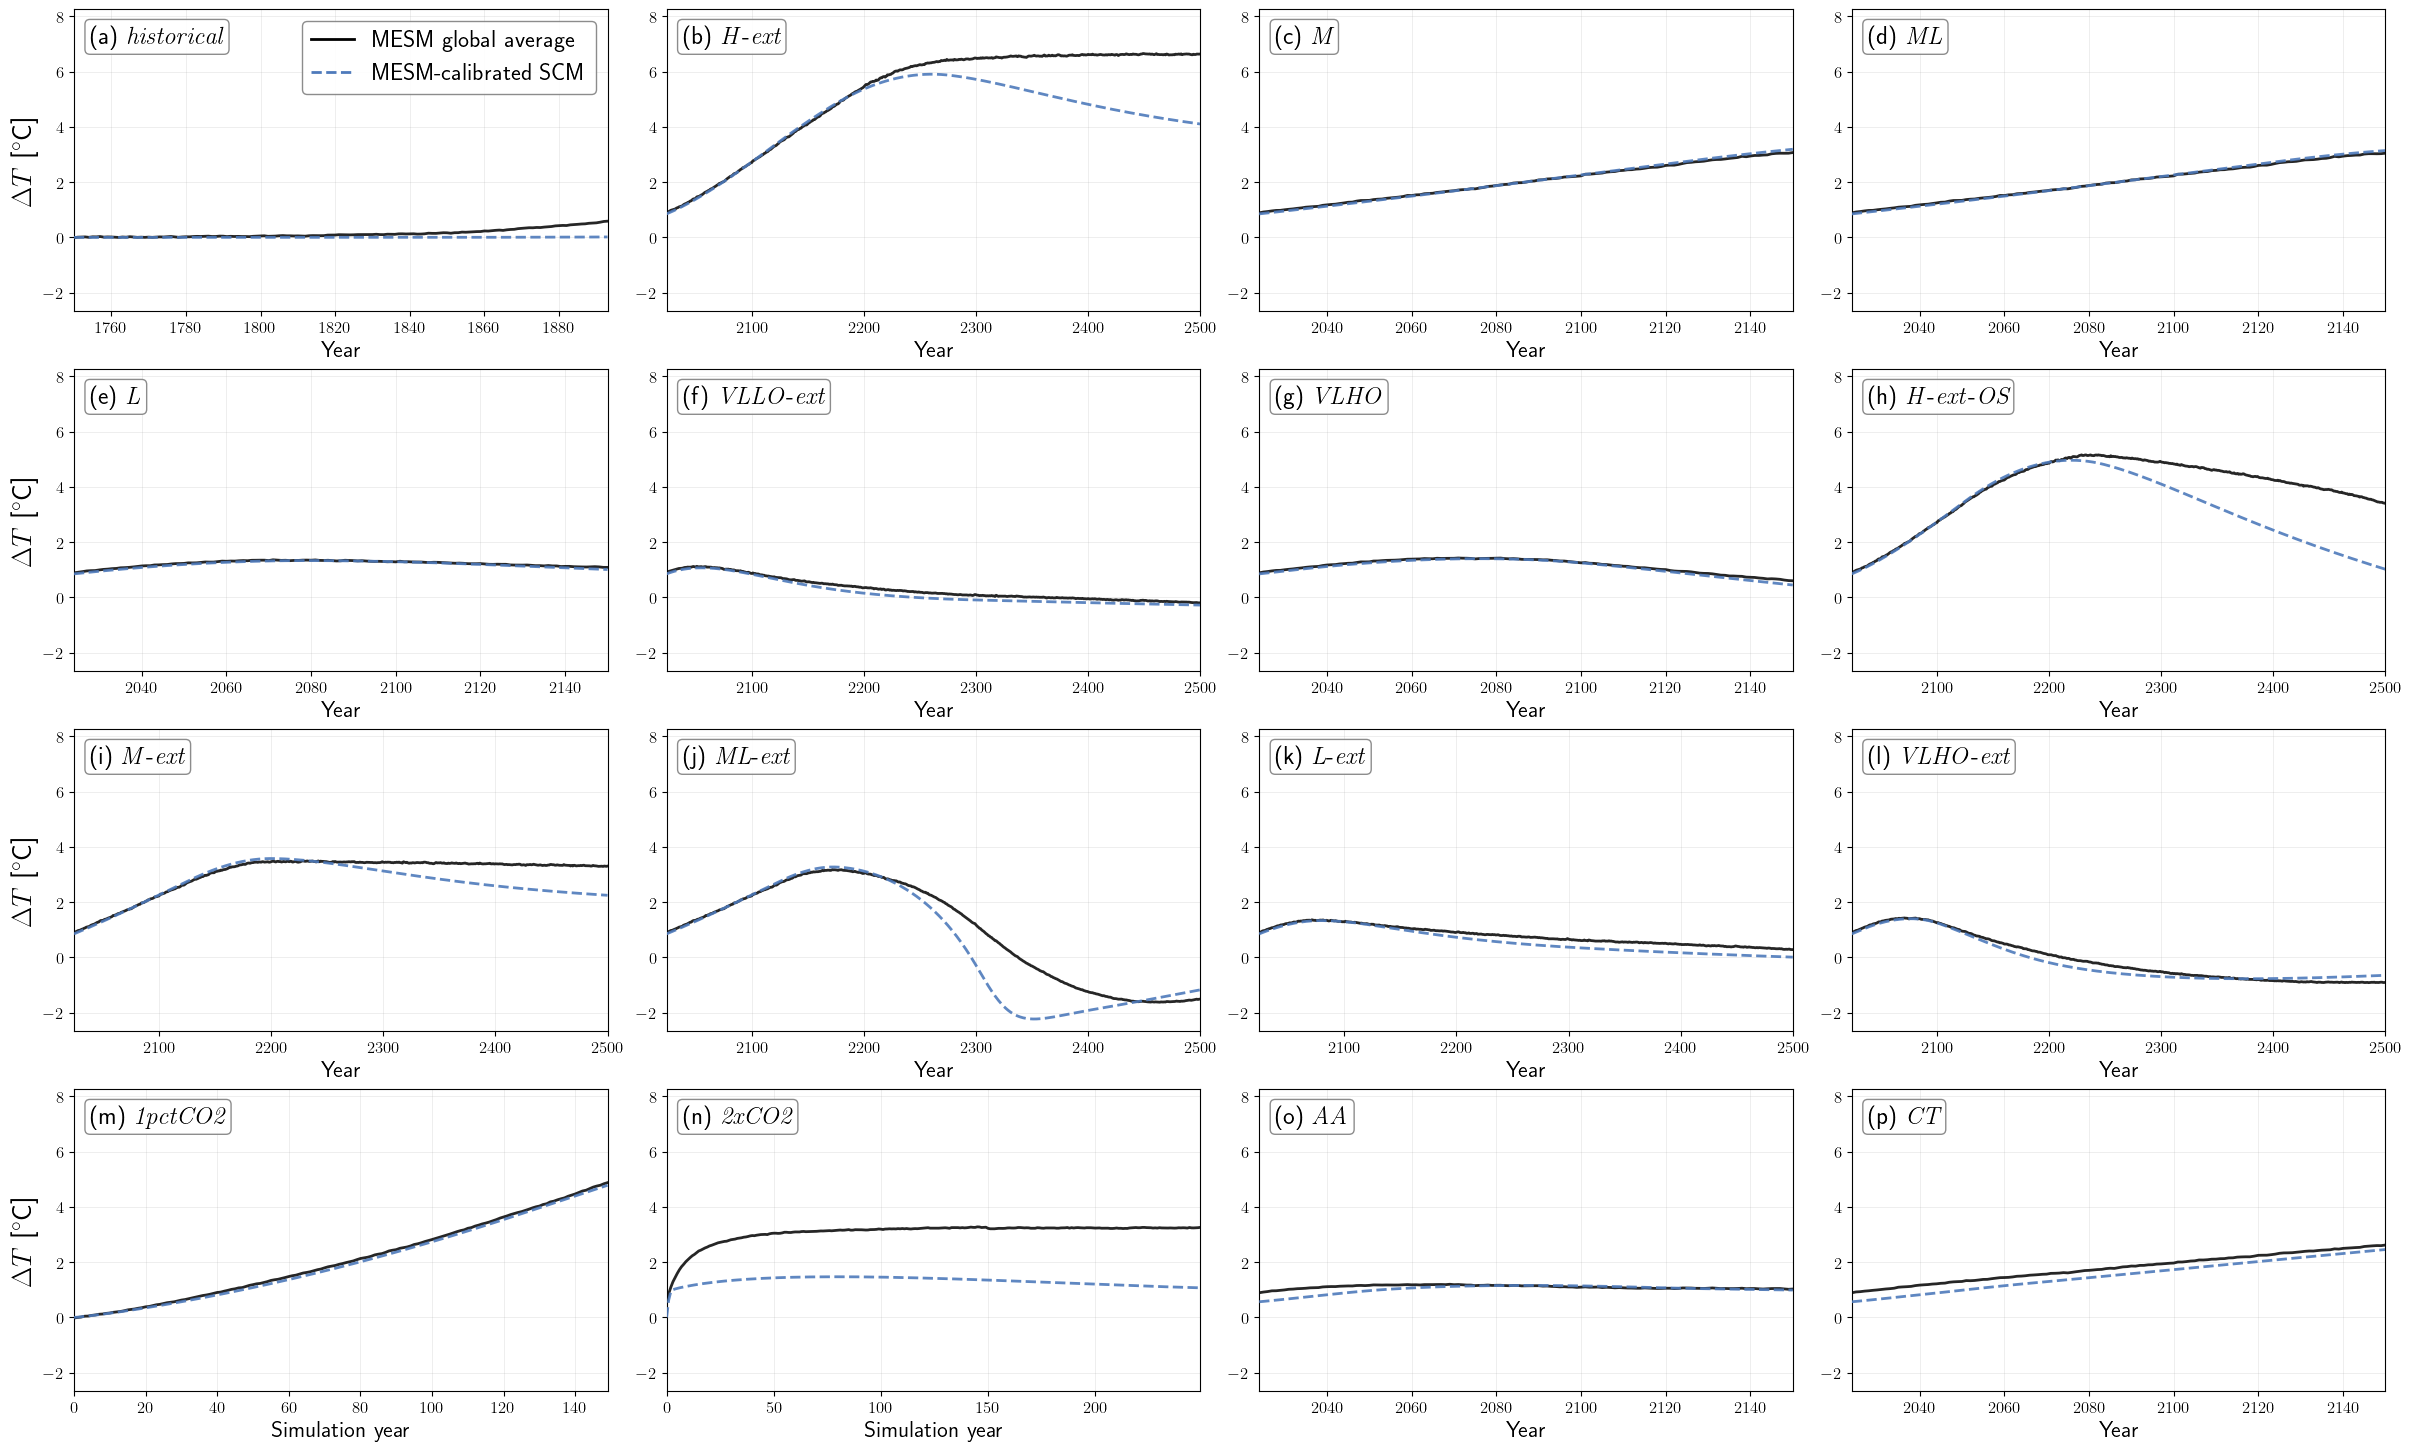

In [12]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_tier1, ncols=4, save="fig_scm_mesm_fidelity_grid_tier1",
)

### Skill assessment

NRMSE for all three parameter sets. The `role_tier1` column marks what is training
data **for the `tier1` column specifically** --- that is the column whose held-out
set shrank by adding Tier 1, and the one to read the extrapolation claim from.

In [13]:
def _df(p, label):
    d = pd.DataFrame([{k: q[k] for k in ("set_name", "scenario", "nrmse", "r2")} for q in p])
    return d.rename(columns={"nrmse": f"nrmse_{label}", "r2": f"r2_{label}"})

cmp = (_df(panels_base, "base")
       .merge(_df(panels, "deck"), on=["set_name", "scenario"])
       .merge(_df(panels_tier1, "tier1"), on=["set_name", "scenario"]))

def _role(r):
    if r.set_name == "Tier 1":
        return "TRAIN"
    if r.set_name == "DECK":
        return "TRAIN" if r.scenario == "1pctCO2" else "held out"
    return "held out"
cmp["role_tier1"] = [_role(r) for r in cmp.itertuples()]
cmp = cmp.sort_values(["role_tier1", "set_name", "scenario"]).reset_index(drop=True)

pd.set_option("display.width", 250)
print(cmp[["set_name", "scenario", "role_tier1", "nrmse_base", "nrmse_deck", "nrmse_tier1"]]
      .to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

print("\n=== mean NRMSE by scenario set ===")
print(cmp.groupby("set_name")[["nrmse_base", "nrmse_deck", "nrmse_tier1"]].mean()
      .to_string(float_format=lambda v: f"{v:7.3f}"))

held = cmp[cmp["role_tier1"] == "held out"]
train = cmp[cmp["role_tier1"] == "TRAIN"]
print("\n=== headline (rows grouped by their role for the `tier1` fit) ===")
print(f"  TRAIN    (Tier 1 + 1pctCO2) : base {train['nrmse_base'].mean():.3f} | "
      f"deck {train['nrmse_deck'].mean():.3f} | tier1 {train['nrmse_tier1'].mean():.3f}")
print(f"  HELD OUT (Tier 2+CS3+2xCO2) : base {held['nrmse_base'].mean():.3f} | "
      f"deck {held['nrmse_deck'].mean():.3f} | tier1 {held['nrmse_tier1'].mean():.3f}")
print(f"  ALL                         : base {cmp['nrmse_base'].mean():.3f} | "
      f"deck {cmp['nrmse_deck'].mean():.3f} | tier1 {cmp['nrmse_tier1'].mean():.3f}")
print(f"\n  held-out scenarios where tier1 beats baseline: "
      f"{(held['nrmse_tier1'] < held['nrmse_base']).sum()} / {len(held)}")

set_name   scenario role_tier1  nrmse_base  nrmse_deck  nrmse_tier1
    DECK    1pctCO2      TRAIN       0.014       0.007        0.017
  Tier 1      H-ext      TRAIN       0.158       0.212        0.179
  Tier 1          L      TRAIN       0.120       0.093        0.027
  Tier 1          M      TRAIN       0.018       0.005        0.016
  Tier 1         ML      TRAIN       0.019       0.006        0.015
  Tier 1       VLHO      TRAIN       0.153       0.127        0.043
  Tier 1   VLLO-ext      TRAIN       0.157       0.143        0.126
  Tier 1 historical      TRAIN       0.350       0.350        0.351
     CS3         AA   held out       0.141       0.123        0.123
     CS3         CT   held out       0.114       0.101        0.102
    DECK      2xCO2   held out       0.588       0.575        0.547
  Tier 2   H-ext-OS   held out       0.208       0.256        0.231
  Tier 2      L-ext   held out       0.198       0.183        0.168
  Tier 2      M-ext   held out       0.132      

### Per-scenario comparison

Bars show NRMSE change relative to the existing baseline; below zero = better.
Orange bars are training data for the `tier1` fit, blue are held out.

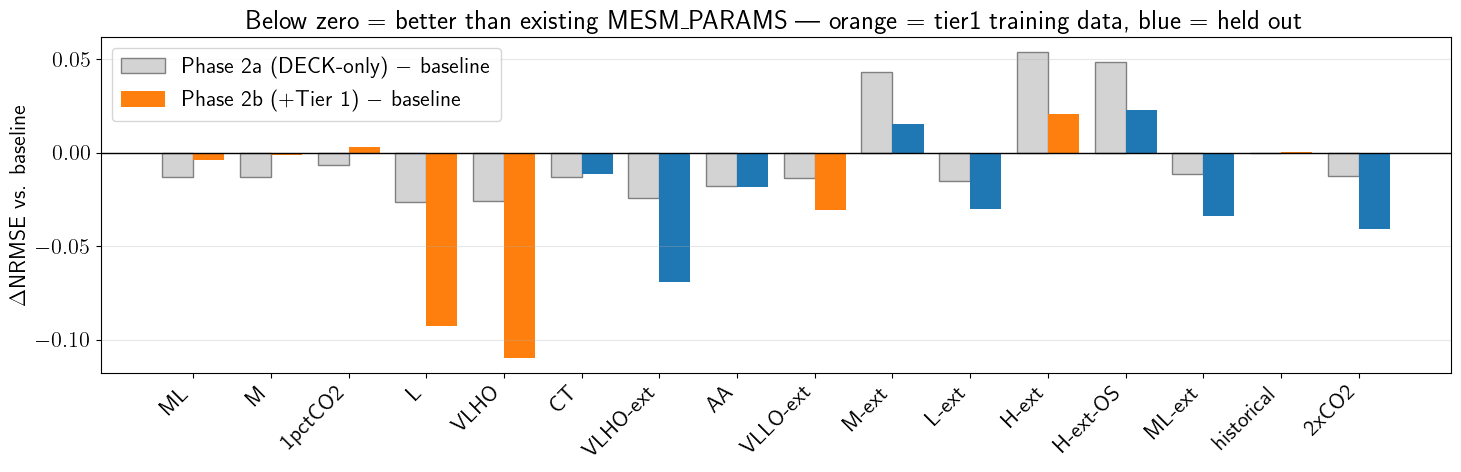

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))
order = cmp.sort_values("nrmse_tier1").reset_index(drop=True)
idx = np.arange(len(order))
cols = ["tab:orange" if r == "TRAIN" else "tab:blue" for r in order["role_tier1"]]
ax.bar(idx - 0.2, order["nrmse_deck"] - order["nrmse_base"], width=0.4,
       color="lightgrey", edgecolor="grey", label="Phase 2a (DECK-only) $-$ baseline")
ax.bar(idx + 0.2, order["nrmse_tier1"] - order["nrmse_base"], width=0.4,
       color=cols, label="Phase 2b (+Tier 1) $-$ baseline")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(idx)
ax.set_xticklabels(order["scenario"], rotation=45, ha="right")
ax.set_ylabel(r"$\Delta$NRMSE vs. baseline")
ax.set_title("Below zero = better than existing MESM_PARAMS   |   orange = tier1 training data, blue = held out")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Part 3: Diagnostic --- score 2xCO2 concentration-driven, not emissions-driven

DECK's `2xCO2` panel is the single worst-fitting scenario throughout Part 2, and
diagnosis (outside this notebook, see conversation) traced it to the **carbon
cycle**, not the thermal fit: driven by MESM's own implied emissions (a 632 GtC
year-1 pulse), our carbon cycle -- fitted only against 1pctCO2's smooth 1%/yr ramp
-- drains the pulse away instead of holding a 2x plateau (352 ppm at year 249,
vs. the 572.8 ppm hold a true doubling requires). That is a genuine, separate gap
from the thermal-response work above, and no amount of retuning $d$/$q$ can fix it.

But `abrupt-2xCO2` is not actually an emissions-driven experiment: MESM was run
concentration-prescribed (the implied-emissions file is MESM's own *diagnosed*
output, not what it was forced with). Scoring our emissions-driven emulator
against it is a strictly harder test than the experiment was designed for --
it demands our carbon cycle be the exact inverse of MESM's own, which the 150-year
ramp used to fit it never constrained.

This diagnostic rescopes just the `2xCO2` panel to match how the experiment was
actually run: prescribe its concentration (2x flat, exactly as Phase 2 already
does) and score only the thermal response, `simulate_temp_prescribed_conc`,
bypassing the carbon cycle entirely. Every other panel is unchanged --
still the full emissions -> concentration -> temperature pipeline.

In [12]:
def scm_2xco2_concdriven(params):
    """2xCO2 GMST under prescribed concentration (bypasses the carbon cycle),
    same construction as Phase 2's own conc_dict_both/emis_dict_climate_both."""
    conc = jnp.zeros((3, n_years_2xco2))
    conc = conc.at[0,:].set(2*base_co2).at[1,:].set(720.0).at[2,:].set(270.0)
    emis0 = jnp.zeros((5, n_years_2xco2))
    years = jnp.arange(n_years_2xco2, dtype=jnp.float32)
    return np.asarray(utils_FaIR_JAX.simulate_temp_prescribed_conc(years, conc, emis0, params, dt=0.1))

def rescope_2xco2(panels, params):
    """Copy `panels`, replacing DECK/2xCO2's scm array + NRMSE/R2 with the
    concentration-driven diagnostic (mesm truth / x-axis unchanged)."""
    out = []
    for p in panels:
        if p["set_name"] == "DECK" and p["scenario"] == "2xCO2":
            p = dict(p)
            n = len(p["mesm"])
            scm_diag = scm_2xco2_concdriven(params)[:n]
            nrmse, r2, _ = s6d.nrmse_r2(scm_diag, p["mesm"])
            p["scm"], p["nrmse"], p["r2"] = scm_diag, nrmse, r2
        out.append(p)
    return out

panels_base_diag  = rescope_2xco2(panels_base,  utils_FaIR_JAX.MESM_PARAMS)
panels_deck_diag  = rescope_2xco2(panels,       params_split)
panels_tier1_diag = rescope_2xco2(panels_tier1, params_tier1)

_before = next(p for p in panels_tier1 if p["set_name"]=="DECK" and p["scenario"]=="2xCO2")
_after  = next(p for p in panels_tier1_diag if p["set_name"]=="DECK" and p["scenario"]=="2xCO2")
print(f"2xCO2 NRMSE (tier1 params): emissions-driven {_before['nrmse']:.3f} -> "
      f"concentration-driven {_after['nrmse']:.3f}")
print(f"2xCO2 R2    (tier1 params): emissions-driven {_before['r2']:.3f} -> "
      f"concentration-driven {_after['r2']:.3f}")

2xCO2 NRMSE (tier1 params): emissions-driven 0.547 -> concentration-driven 0.201
2xCO2 R2    (tier1 params): emissions-driven -18.706 -> concentration-driven -1.662


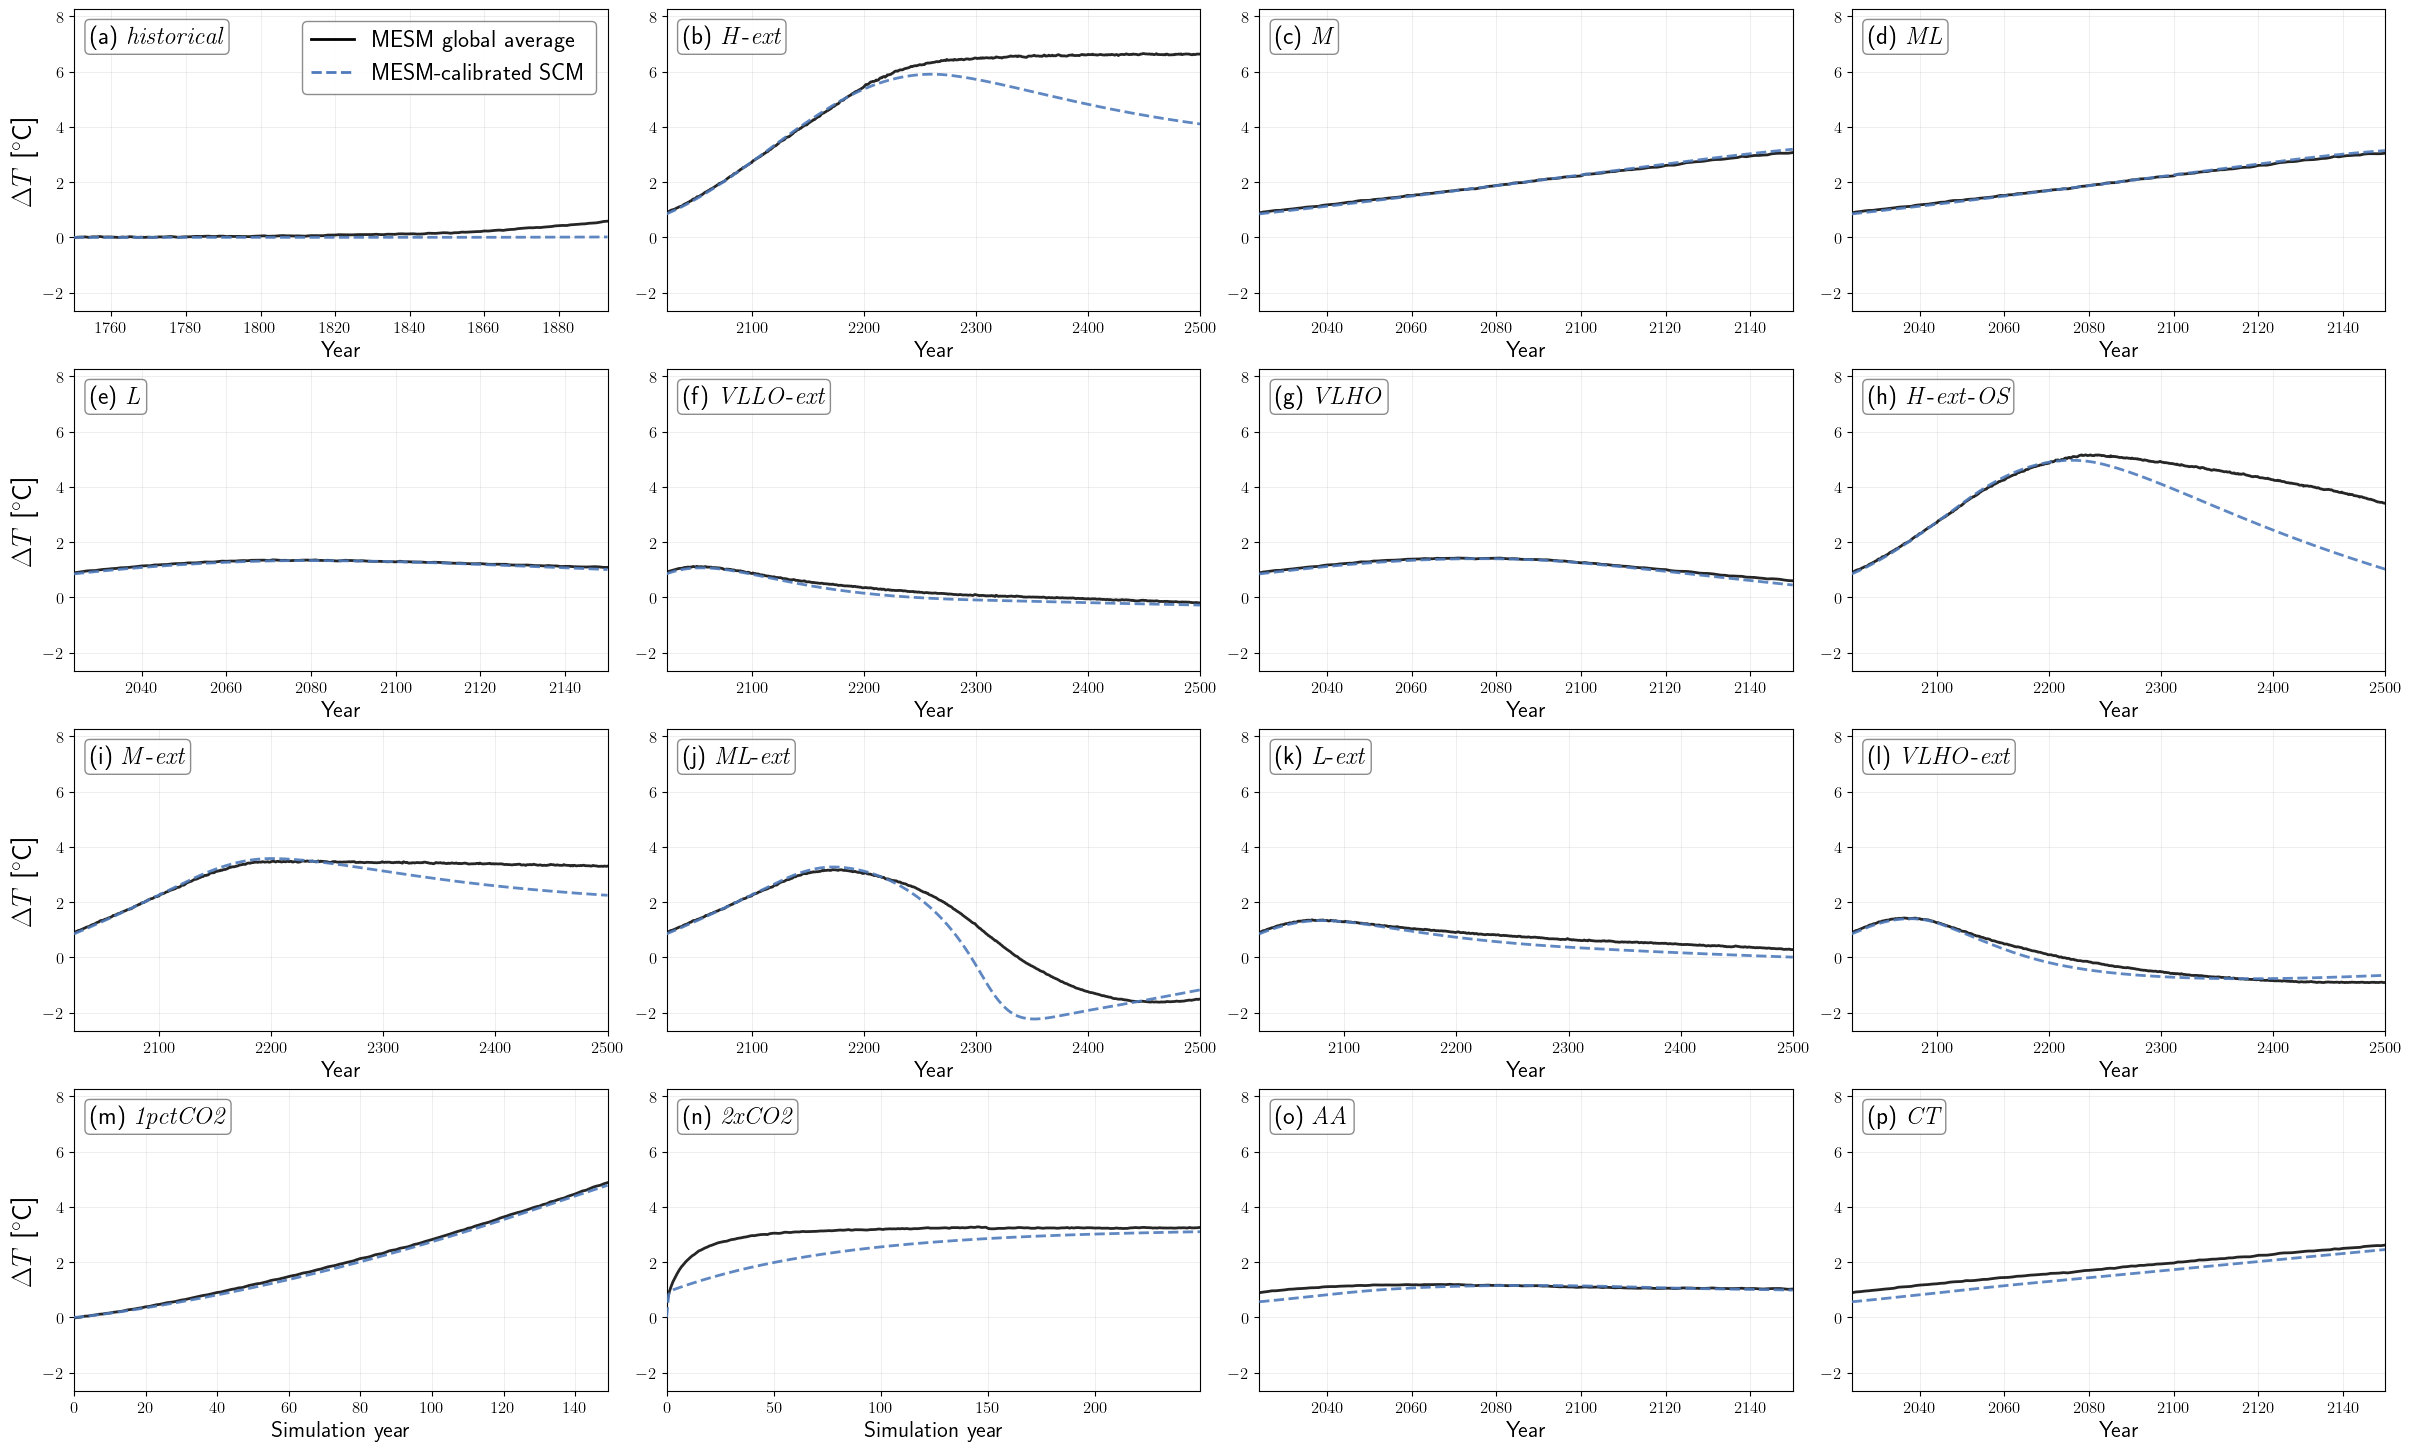

In [16]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_tier1_diag, ncols=4, save="fig_scm_mesm_fidelity_grid_tier1_2xco2diag",
)

### Skill table with the diagnostic applied

In [17]:
def _df2(p, label):
    d = pd.DataFrame([{k: q[k] for k in ("set_name", "scenario", "nrmse", "r2")} for q in p])
    return d.rename(columns={"nrmse": f"nrmse_{label}", "r2": f"r2_{label}"})

cmp_diag = (_df2(panels_base_diag, "base")
            .merge(_df2(panels_deck_diag, "deck"), on=["set_name", "scenario"])
            .merge(_df2(panels_tier1_diag, "tier1"), on=["set_name", "scenario"]))
cmp_diag["role_tier1"] = [_role(r) for r in cmp_diag.itertuples()]
cmp_diag = cmp_diag.sort_values(["role_tier1", "set_name", "scenario"]).reset_index(drop=True)

print(cmp_diag[["set_name", "scenario", "role_tier1", "nrmse_base", "nrmse_deck", "nrmse_tier1"]]
      .to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

held_d = cmp_diag[cmp_diag["role_tier1"] == "held out"]
train_d = cmp_diag[cmp_diag["role_tier1"] == "TRAIN"]
print("\n=== headline, 2xCO2 concentration-driven ===")
print(f"  TRAIN    : base {train_d['nrmse_base'].mean():.3f} | deck {train_d['nrmse_deck'].mean():.3f} | tier1 {train_d['nrmse_tier1'].mean():.3f}")
print(f"  HELD OUT : base {held_d['nrmse_base'].mean():.3f} | deck {held_d['nrmse_deck'].mean():.3f} | tier1 {held_d['nrmse_tier1'].mean():.3f}")
print(f"  ALL      : base {cmp_diag['nrmse_base'].mean():.3f} | deck {cmp_diag['nrmse_deck'].mean():.3f} | tier1 {cmp_diag['nrmse_tier1'].mean():.3f}")
print(f"\n  (compare to emissions-driven 2xCO2: ALL was base {cmp['nrmse_base'].mean():.3f} | "
      f"deck {cmp['nrmse_deck'].mean():.3f} | tier1 {cmp['nrmse_tier1'].mean():.3f})")

set_name   scenario role_tier1  nrmse_base  nrmse_deck  nrmse_tier1
    DECK    1pctCO2      TRAIN       0.014       0.007        0.017
  Tier 1      H-ext      TRAIN       0.158       0.212        0.179
  Tier 1          L      TRAIN       0.120       0.093        0.027
  Tier 1          M      TRAIN       0.018       0.005        0.016
  Tier 1         ML      TRAIN       0.019       0.006        0.015
  Tier 1       VLHO      TRAIN       0.153       0.127        0.043
  Tier 1   VLLO-ext      TRAIN       0.157       0.143        0.126
  Tier 1 historical      TRAIN       0.350       0.350        0.351
     CS3         AA   held out       0.141       0.123        0.123
     CS3         CT   held out       0.114       0.101        0.102
    DECK      2xCO2   held out       0.229       0.216        0.201
  Tier 2   H-ext-OS   held out       0.208       0.256        0.231
  Tier 2      L-ext   held out       0.198       0.183        0.168
  Tier 2      M-ext   held out       0.132      

### Revision scenarios --- figure and skill table

Appends the three revision panels to the adopted (Tier1-augmented, 2xCO2
concentration-driven-diagnostic) grid above, saved under a distinct filename so
`fig_scm_mesm_fidelity_grid_tier1_2xco2diag` above is left unchanged.


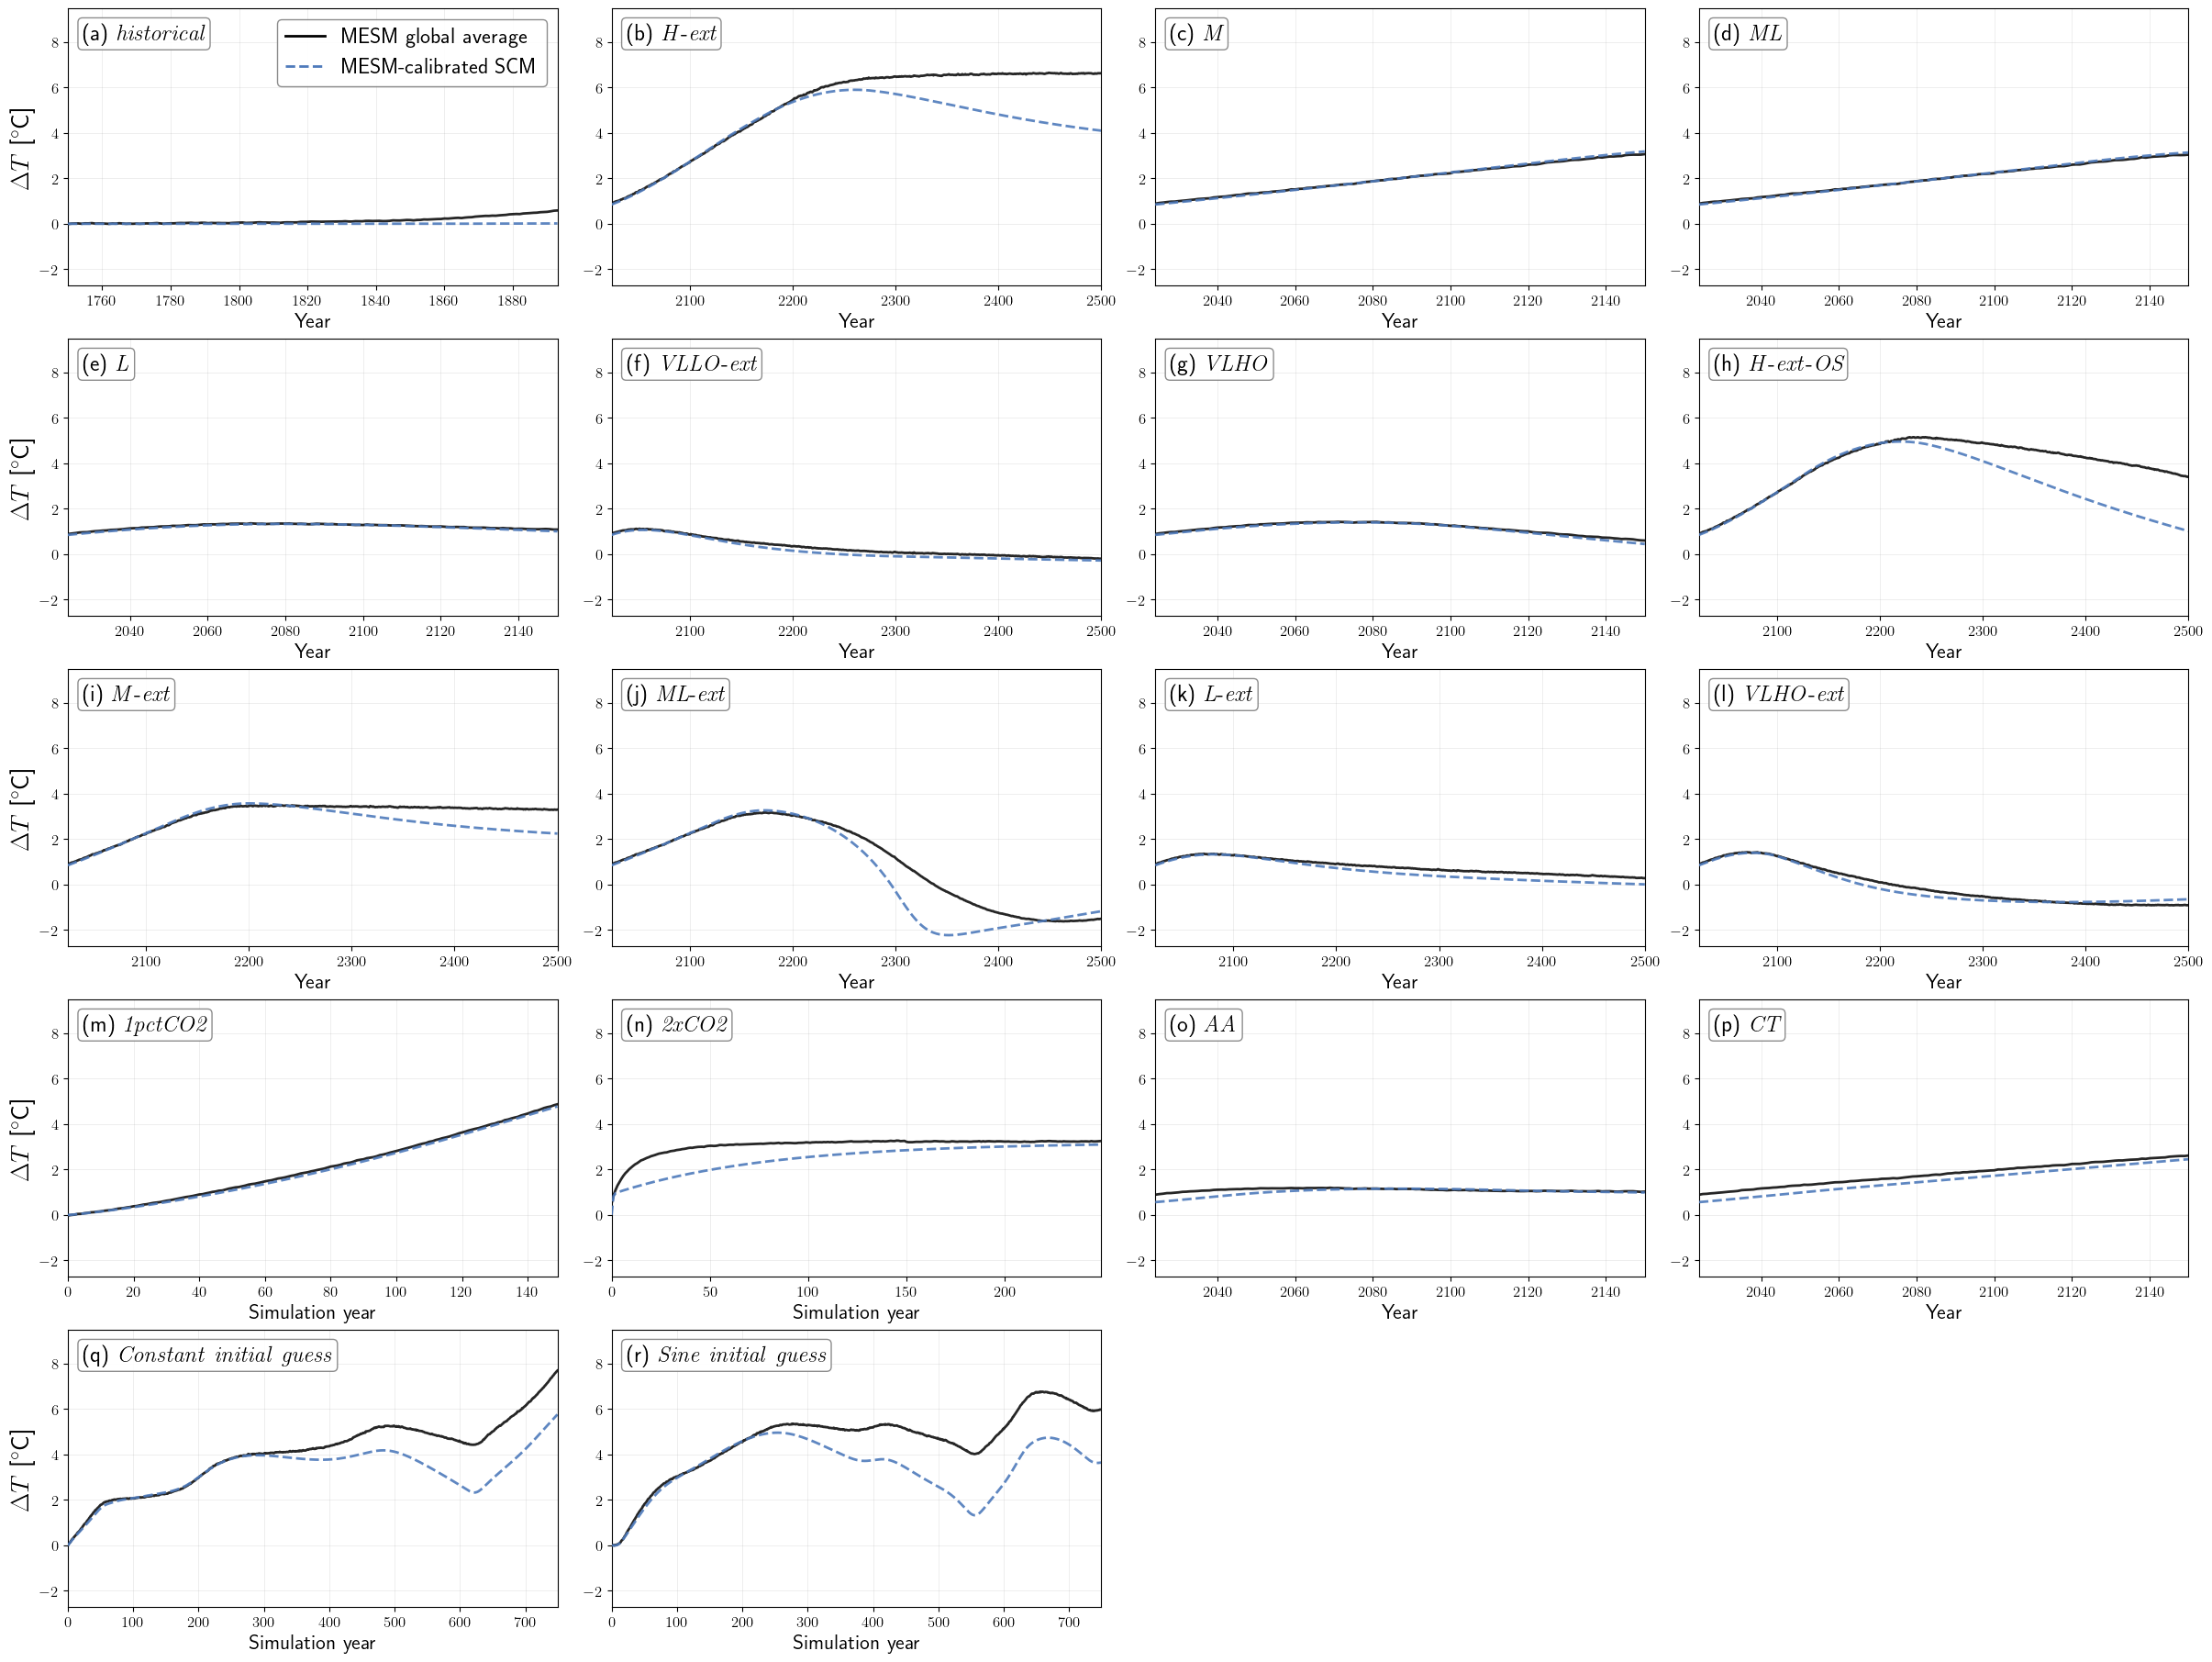

In [13]:
# Figure-only subset: drop Gaussian, and rename the remaining two to plain
# "Constant initial guess" / "Sine initial guess" (no "Rev-" prefix) for
# display. revision_panels_tier1 itself (all three ICs, "Rev-{ic}" scenario
# names) is left untouched - the comparison tables above key off those names.
# The plotting function's _italic_scenario wraps a hyphen-free name in one
# single $\it{...}$ math block, and LaTeX math mode collapses plain spaces
# - so the words need an explicit "\ " between them to actually render as
# separate words instead of running together.
_rev_fig_display = {"constant": r"Constant\ initial\ guess", "sine": r"Sine\ initial\ guess"}
panels_tier1_2xco2diag_revision = panels_tier1_diag + [
    {**p, "scenario": _rev_fig_display[ic]}
    for ic, p in zip(REV_ICS, revision_panels_tier1) if ic in _rev_fig_display
]

fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_tier1_2xco2diag_revision, ncols=4,
    save="fig_scm_mesm_fidelity_grid_tier1_2xco2diag_revision",
)


In [19]:
cmp_rev = (_df2(revision_panels_base, "base")
           .merge(_df2(revision_panels_deck, "deck"), on=["set_name", "scenario"])
           .merge(_df2(revision_panels_tier1, "tier1"), on=["set_name", "scenario"]))

print(cmp_rev[["scenario", "nrmse_base", "nrmse_deck", "nrmse_tier1", "r2_base", "r2_deck", "r2_tier1"]]
      .to_string(index=False, float_format=lambda v: f"{v:7.3f}"))
print(f"\n  mean NRMSE across the three revision scenarios: "
      f"base {cmp_rev['nrmse_base'].mean():.3f} | deck {cmp_rev['nrmse_deck'].mean():.3f} | "
      f"tier1 {cmp_rev['nrmse_tier1'].mean():.3f}")
print(f"  (compare to the existing 16-scenario ALL row: base {cmp_diag['nrmse_base'].mean():.3f} | "
      f"deck {cmp_diag['nrmse_deck'].mean():.3f} | tier1 {cmp_diag['nrmse_tier1'].mean():.3f})")


    scenario  nrmse_base  nrmse_deck  nrmse_tier1  r2_base  r2_deck  r2_tier1
Rev-constant       0.110       0.148        0.143    0.692    0.446     0.480
    Rev-sine       0.184       0.232        0.226    0.295   -0.129    -0.063
Rev-gaussian       0.230       0.256        0.238    0.667    0.588     0.642

  mean NRMSE across the three revision scenarios: base 0.175 | deck 0.212 | tier1 0.202
  (compare to the existing 16-scenario ALL row: base 0.156 | deck 0.153 | tier1 0.133)


### State of the carbon cycle (Phase 1: 1pctCO2 only)

The thermal-response work above (Phases 2a/2b) doesn't touch the carbon-cycle
parameters at all -- they're frozen at whatever Phase 1 fit, and Phase 1 has been
1pctCO2-only throughout this notebook. Summarizing what that fit actually is,
since it's the piece the diagnostic above just isolated as the real gap.

In [23]:
p1 = utils_FaIR_JAX.params_from_theta(theta_opt_emis, utils_FaIR_JAX.MESM_PARAMS)
a1, tau1 = np.asarray(p1["a"]), np.asarray(p1["tau"])
aF, tauF = np.asarray(utils_FaIR_JAX.FAIR_PARAMS["a"]), np.asarray(utils_FaIR_JAX.FAIR_PARAMS["tau"])
o1, oF = np.argsort(tau1), np.argsort(tauF)

print("Fitted carbon-cycle pools (this notebook's Phase 1, 1pctCO2 only):")
print(f"  tau (yr) = {np.round(tau1[o1], 3)}")
print(f"  a        = {np.round(a1[o1], 3)}   (sum={a1.sum():.3f})")
print(f"\nFaIR default pools, for reference:")
print(f"  tau (yr) = {np.round(tauF[oF], 3)}")
print(f"  a        = {np.round(aF[oF], 3)}   (sum={aF.sum():.3f})")

print(f"\n1pctCO2 fit quality (in-sample): concentration tracks target to within "
      f"~2% at year 149 (see Phase 1 diagnostic plot above).")

print(f"\nWhat that same fit does to MESM's 2xCO2 implied-emissions pulse "
      f"(632 GtC in year 1, {632+95:.0f} GtC cumulative by year 10):")
emis_2x_path = f"{DATA_DIR / 'MESM' / 'emis_driven'}/2xCO2/implco2emiss.3100.25.txt"
e2x = np.loadtxt(emis_2x_path, usecols=(2,))
emat = jnp.zeros((5, len(e2x))).at[0,:].set(e2x)
out2x = utils_FaIR_JAX.simulate_temp(jnp.arange(len(e2x), dtype=jnp.float32), emat,
                                     mode="MESM", params=p1, dt=0.1)
c2x = np.asarray(out2x["Catm_ppm"])
print(f"  simulated CO2: yr1={c2x[0]:.0f}  yr10={c2x[9]:.0f}  yr50={c2x[49]:.0f}  "
      f"yr150={c2x[149]:.0f}  yr249={c2x[248]:.0f} ppm   (MESM target: flat {2*base_co2:.1f} ppm)")
frac_airborne = a1[np.argmin(tau1)]
print(f"\n  {frac_airborne*100:.0f}% of a1's pool partition sits in the "
      f"{tau1[np.argmin(tau1)]:.2f}-year timescale -- fine for absorbing/releasing "
      f"carbon smoothly under a slow ramp (where it re-equilibrates every step),")
print(f"  but it dumps most of a one-year pulse's mass within the same year it "
      f"arrives, rather than the ~30% MESM's own carbon cycle actually retained "
      f"as long-lived airborne CO2 (870 GtC emitted vs 607 GtC needed for the "
      f"atmospheric burden increase -> MESM's own land+ocean absorbed 263 GtC, "
      f"~30%, not ~85% within a decade).")
print(f"\n  Net: this carbon cycle is well-constrained for smooth, ramp-like "
      f"forcing and essentially unconstrained for pulse-like forcing -- a real "
      f"identifiability gap left open by fitting to 1pctCO2 alone, mirroring "
      f"exactly the ECS-from-a-ramp gap the thermal fit had (and fixed by "
      f"pinning from abrupt-2xCO2's equilibrium).")

Fitted carbon-cycle pools (this notebook's Phase 1, 1pctCO2 only):
  tau (yr) = [8.8099998e-01 7.8049998e+00 1.2308200e+02 2.5120505e+05]
  a        = [0.78  0.129 0.049 0.041]   (sum=1.000)

FaIR default pools, for reference:
  tau (yr) = [2.266000e+00 1.474000e+01 2.195520e+02 4.457485e+05]
  a        = [0.424 0.354 0.121 0.102]   (sum=1.000)

1pctCO2 fit quality (in-sample): concentration tracks target to within ~2% at year 149 (see Phase 1 diagnostic plot above).

What that same fit does to MESM's 2xCO2 implied-emissions pulse (632 GtC in year 1, 727 GtC cumulative by year 10):
  simulated CO2: yr1=316  yr10=555  yr50=453  yr150=379  yr249=352 ppm   (MESM target: flat 572.8 ppm)

  78% of a1's pool partition sits in the 0.88-year timescale -- fine for absorbing/releasing carbon smoothly under a slow ramp (where it re-equilibrates every step),
  but it dumps most of a one-year pulse's mass within the same year it arrives, rather than the ~30% MESM's own carbon cycle actually retaine

## Part 4: Option 2 --- add the 2xCO2 pulse to the carbon-cycle fit

Part 3 traced 2xCO2's persistent emissions-driven failure to the carbon cycle: fitted
only against 1pctCO2's smooth 1%/yr ramp, its pool partition puts 78% of a pulse's
mass in a sub-1-year pool -- fine for a ramp, wrong for a pulse. This section (Option
2 from the earlier check-in) refits the carbon cycle **jointly** against 1pctCO2 and
MESM's own implied-emissions 2xCO2 pulse (`emis_dict['2xCO2']`, loaded in cell 2 --
the same column `scripts/6d_scm_mesm_fidelity.py` and `utils_inverse.py` use
everywhere else in this codebase for DECK/2xCO2), then re-chains the thermal-timescale
fits (Phase 2a, 2b) from the result exactly as before, so the full comparison is
apples-to-apples with Part 2/3's tier1 result.

`normalize_per_scenario=True` is required here -- the pulse's year-1 value
(~2318 GtC) and the ramp's peak (~34 GtC/yr) are two orders of magnitude apart, and
an unnormalized joint MSE would be dominated entirely by the pulse.

In [24]:
# Phase 1b: joint carbon-cycle fit, 1pctCO2 + 2xCO2's implied-emissions pulse.
# Reuses `emis_dict` (both experiments' real/implied emissions, built in cell 2)
# and `conc_mat_2xco2` (Phase 2's own flat 2x target, built in cell 8) so the
# pulse target here is identical to what Phase 2 already treats as "true 2xCO2".
target_conc_dict_1pct_2xco2 = {
    '1pctCO2': target_conc_dict_1pct['1pctCO2'],
    '2xCO2': conc_mat_2xco2,
}

CARBON_FILEPATH_V2 = 'data/JAX_calibration/calib_MESM_emis_to_conc_1pct_2xco2.pkl'

# Starts fresh from theta0 (not chained from Phase 1's theta_opt_emis), matching
# Phase 1's own convention -- an independent, unbiased joint fit rather than a
# refinement of the ramp-only optimum. 800 steps: the joint loss plateaus around
# step 600-900 in prototyping: further steps just add Adam noise, not signal.
theta_opt_emis_v2, _ = utils_FaIR_JAX.calibrate_carbon_cycle(
    CARBON_FILEPATH_V2, emis_dict, target_conc_dict_1pct_2xco2, theta0, dt=0.1, n_steps=800,
    learning_rate=1e-2, mode='FaIR', base_params=utils_FaIR_JAX.MESM_PARAMS,
    normalize_per_scenario=True,
)

_p1b = utils_FaIR_JAX.params_from_theta(theta_opt_emis_v2, utils_FaIR_JAX.MESM_PARAMS)
_a1b, _tau1b = np.asarray(_p1b['a']), np.asarray(_p1b['tau'])
_o1b = np.argsort(_tau1b)
print(f"\n  fitted a   = {np.round(_a1b[_o1b], 3)}  (sum={_a1b.sum():.3f})")
print(f"  fitted tau = {np.round(_tau1b[_o1b], 2)}")

_co2_1pct_target = base_co2 * (1.01 ** np.arange(len(emis_1pct)))
_out1b = utils_FaIR_JAX.simulate_temp(jnp.arange(len(emis_1pct), dtype=jnp.float32),
                                      emis_mat_1pct, mode='MESM', params=_p1b, dt=0.1)
_c1b = np.asarray(_out1b['Catm_ppm'])
print(f"\n  1pctCO2 (in-sample): yr70={_c1b[69]:.0f} (target {_co2_1pct_target[69]:.0f})  "
      f"yr149={_c1b[148]:.0f} (target {_co2_1pct_target[148]:.0f})")

_out2b = utils_FaIR_JAX.simulate_temp(jnp.arange(len(emis_2xco2), dtype=jnp.float32),
                                      emis_mat_2xco2, mode='MESM', params=_p1b, dt=0.1)
_c2b = np.asarray(_out2b['Catm_ppm'])
print(f"  2xCO2 pulse (in-sample): yr1={_c2b[0]:.0f} yr10={_c2b[9]:.0f} yr50={_c2b[49]:.0f} "
      f"yr150={_c2b[149]:.0f} yr249={_c2b[248]:.0f} ppm  (target flat {2*base_co2:.1f})")

Starting Carbon Cycle Calibration (Emis -> Conc)...


Step 0 | Loss (Conc MSE): 0.0680


Step 100 | Loss (Conc MSE): 0.0320


Step 200 | Loss (Conc MSE): 0.0072


Step 300 | Loss (Conc MSE): 0.0066


Step 400 | Loss (Conc MSE): 0.0062


Step 500 | Loss (Conc MSE): 0.0059


Step 600 | Loss (Conc MSE): 0.0057


Step 700 | Loss (Conc MSE): 0.0055


Step 799 | Loss (Conc MSE): 0.0055

  fitted a   = [0.213 0.103 0.069 0.615]  (sum=1.000)
  fitted tau = [8.2999998e-01 2.0450001e+01 1.9039200e+03 1.3925604e+07]

  1pctCO2 (in-sample): yr70=610 (target 569)  yr149=1401 (target 1249)
  2xCO2 pulse (in-sample): yr1=316 yr10=520 yr50=545 yr150=556 yr249=547 ppm  (target flat 572.8)


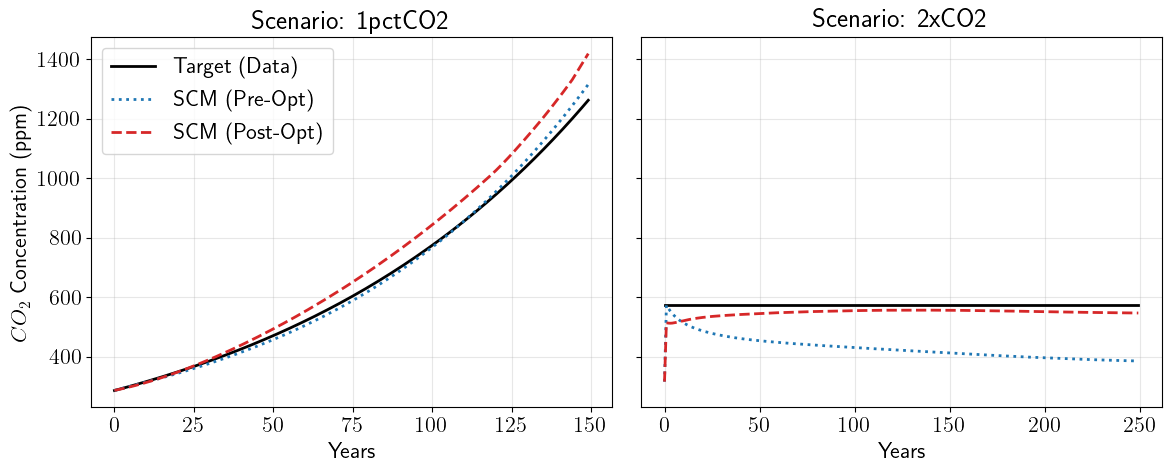

In [25]:
utils_plotting.plot_calibration_results(
    None, emis_dict, target_conc_dict_1pct_2xco2, theta0, theta_opt_emis_v2, dt=0.1,
    calib='Carbon', base_params=utils_FaIR_JAX.MESM_PARAMS,
)

### Re-chain the thermal fit from Phase 1b

Same Phase 2a/2b procedure as Part 1/2 -- ECS still pinned from abrupt-2xCO2's
equilibrium, timescales fit to 1pctCO2 (2a) then 1pctCO2+Tier 1 (2b) -- but starting
from `theta_opt_emis_v2` instead of `theta_opt_emis`, so the carbon-cycle parameters
feeding into concentration -> temperature are Phase 1b's throughout. `conc_dict_fit`,
`target_dict_fit`, `emis_dict_climate_fit`, `sum_q_target`, `per_scen_t1`, `TRAIN_T1`,
`vg_t1` and `w_t1` are all unchanged from Part 1 -- Phase 2 prescribes concentration
directly and never touches the carbon cycle, so only the starting theta differs.

In [26]:
CLIMATE_FILEPATH_V2 = 'data/JAX_calibration/calib_MESM_CO2_only_1pct_2xco2carbon.pkl'

theta_opt_v2, _ = utils_FaIR_JAX.calibrate_climate_sensitivity(
    CLIMATE_FILEPATH_V2, emis_dict_climate_fit, conc_dict_fit, target_dict_fit, theta_opt_emis_v2,
    dt=0.1, n_steps=1000, learning_rate=1e-2, base_params=utils_FaIR_JAX.MESM_PARAMS,
    sum_q_target=sum_q_target,
)

_pf2 = utils_FaIR_JAX.params_from_theta(theta_opt_v2, utils_FaIR_JAX.MESM_PARAMS)
_o2 = np.argsort(np.asarray(_pf2['d']))
print(f"\n  fitted d (yr) = {np.round(np.asarray(_pf2['d'])[_o2], 2)}")
print(f"  fitted q      = {np.round(np.asarray(_pf2['q'])[_o2], 4)}  (sum={float(jnp.sum(_pf2['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pf2['q'])):.2f} K (pinned to MESM's {mesm_ecs:.2f} K)")

Starting Climate Sensitivity Calibration (Conc -> Temp)...
Step 0 | Loss (Temp MSE): 0.0868
Step 100 | Loss (Temp MSE): 0.0018
Step 200 | Loss (Temp MSE): 0.0015


Step 300 | Loss (Temp MSE): 0.0014
Step 400 | Loss (Temp MSE): 0.0013
Step 500 | Loss (Temp MSE): 0.0012
Step 600 | Loss (Temp MSE): 0.0011
Step 700 | Loss (Temp MSE): 0.0010
Step 800 | Loss (Temp MSE): 0.0010
Step 900 | Loss (Temp MSE): 0.0009
Step 999 | Loss (Temp MSE): 0.0008

  fitted d (yr) = [  0.7   17.43 179.65]
  fitted q      = [0.2123 0.269  0.3677]  (sum=0.8490)
  => ECS = 3.20 K (pinned to MESM's 3.20 K)


In [27]:
N_STEPS_T1_V2 = 300
theta_t1_v2 = theta_opt_emis_v2                 # chained from Phase 1b's carbon cycle
opt_state_v2 = opt.init(theta_t1_v2)

print(f"Tier1-augmented timescale fit (v2, chained from Phase 1b carbon cycle): "
      f"{len(TRAIN_T1)} scenarios, {N_STEPS_T1_V2} steps ...")
for step in range(N_STEPS_T1_V2):
    ls, gs = [], []
    for s in TRAIN_T1:
        l, g = vg_t1[s](theta_t1_v2)
        ls.append(l); gs.append(g)
    loss = jnp.sum(jnp.stack(ls) * w_t1)
    grad = jnp.sum(jnp.stack(gs) * w_t1[:, None], axis=0) * mask_clim
    updates, opt_state_v2 = opt.update(grad, opt_state_v2, theta_t1_v2)
    theta_t1_v2 = optax.apply_updates(theta_t1_v2, updates)
    if (step + 1) % 10 == 0:
        jax.clear_caches()
    if step % 25 == 0 or step == N_STEPS_T1_V2 - 1:
        print(f"  step {step:3d} | length-weighted mean NRMSE: {float(loss):.4f}", flush=True)

theta_opt_t1_v2 = _project_sumq(theta_t1_v2, sum_q_target)

_pt2 = utils_FaIR_JAX.params_from_theta(theta_opt_t1_v2, utils_FaIR_JAX.MESM_PARAMS)
_ot2 = np.argsort(np.asarray(_pt2['d']))
print(f"\n  Phase 2b-v2 d (yr) = {np.round(np.asarray(_pt2['d'])[_ot2], 2)}")
print(f"  Phase 2b-v2 q      = {np.round(np.asarray(_pt2['q'])[_ot2], 4)}  (sum={float(jnp.sum(_pt2['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pt2['q'])):.2f} K (still pinned to MESM's {mesm_ecs:.2f} K)")

Tier1-augmented timescale fit (v2, chained from Phase 1b carbon cycle): 8 scenarios, 300 steps ...


  step   0 | length-weighted mean NRMSE: 0.2559


  step  25 | length-weighted mean NRMSE: 0.2048


  step  50 | length-weighted mean NRMSE: 0.1868


  step  75 | length-weighted mean NRMSE: 0.1774


...

  step 225 | length-weighted mean NRMSE: 0.1596


  step 250 | length-weighted mean NRMSE: 0.1581


  step 275 | length-weighted mean NRMSE: 0.1567


  step 299 | length-weighted mean NRMSE: 0.1555



  Phase 2b-v2 d (yr) = [6.40000e-01 6.26000e+00 1.11119e+03]
  Phase 2b-v2 q      = [0.2012 0.2177 0.4301]  (sum=0.8490)
  => ECS = 3.20 K (still pinned to MESM's 3.20 K)


### Skill table: 1pctCO2-only vs +2xCO2-pulse carbon cycle

Both `tier1_v1` (Part 2's result, carbon cycle from 1pctCO2 alone) and `tier1_v2`
(this section, carbon cycle from 1pctCO2+2xCO2 jointly) are scored with the
concentration-driven 2xCO2 diagnostic applied (Part 3), so the comparison isolates
what the carbon-cycle change did to the thermal fit's skill -- not a re-litigation
of Part 3's own finding. The raw emissions-driven 2xCO2 number is reported first,
since that's the one this section's carbon-cycle change directly targets.

In [28]:
params_split_v2 = utils_FaIR_JAX.params_from_theta(theta_opt_v2, utils_FaIR_JAX.MESM_PARAMS)
params_tier1_v2 = utils_FaIR_JAX.params_from_theta(theta_opt_t1_v2, utils_FaIR_JAX.MESM_PARAMS)

panels_deck_v2  = build_panels(params_split_v2)
panels_tier1_v2 = build_panels(params_tier1_v2)

# 2xCO2, emissions-driven: does the pulse-augmented carbon cycle actually close
# the gap that motivated Part 3's concentration-driven diagnostic?
_b1 = next(p for p in panels_tier1    if p["set_name"] == "DECK" and p["scenario"] == "2xCO2")
_b2 = next(p for p in panels_tier1_v2 if p["set_name"] == "DECK" and p["scenario"] == "2xCO2")
print(f"2xCO2 NRMSE, emissions-driven: Phase 1 (1pctCO2-only) tier1 = {_b1['nrmse']:.3f}  "
      f"->  Phase 1b (+2xCO2 pulse) tier1 = {_b2['nrmse']:.3f}")

# Concentration-driven diagnostic, applied consistently to every column so the
# skill table compares thermal fits on equal footing regardless of carbon-cycle
# version (per Part 3's finding that emissions-driven 2xCO2 is an unfair test).
panels_deck_v2_diag  = rescope_2xco2(panels_deck_v2,  params_split_v2)
panels_tier1_v2_diag = rescope_2xco2(panels_tier1_v2, params_tier1_v2)

cmp_v2 = (_df2(panels_base_diag, "base")
          .merge(_df2(panels_tier1_diag,    "tier1_v1"), on=["set_name", "scenario"])
          .merge(_df2(panels_tier1_v2_diag, "tier1_v2"), on=["set_name", "scenario"]))
cmp_v2["role_tier1"] = [_role(r) for r in cmp_v2.itertuples()]
cmp_v2 = cmp_v2.sort_values(["role_tier1", "set_name", "scenario"]).reset_index(drop=True)

print(cmp_v2[["set_name", "scenario", "role_tier1", "nrmse_base", "nrmse_tier1_v1", "nrmse_tier1_v2"]]
      .to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

held_v2 = cmp_v2[cmp_v2["role_tier1"] == "held out"]
train_v2 = cmp_v2[cmp_v2["role_tier1"] == "TRAIN"]
print("\n=== headline, concentration-driven 2xCO2 (both carbon-cycle versions) ===")
print(f"  TRAIN    : base {train_v2['nrmse_base'].mean():.3f} | "
      f"tier1(1pctCO2-only) {train_v2['nrmse_tier1_v1'].mean():.3f} | "
      f"tier1(+2xCO2 pulse) {train_v2['nrmse_tier1_v2'].mean():.3f}")
print(f"  HELD OUT : base {held_v2['nrmse_base'].mean():.3f} | "
      f"tier1(1pctCO2-only) {held_v2['nrmse_tier1_v1'].mean():.3f} | "
      f"tier1(+2xCO2 pulse) {held_v2['nrmse_tier1_v2'].mean():.3f}")
print(f"  ALL      : base {cmp_v2['nrmse_base'].mean():.3f} | "
      f"tier1(1pctCO2-only) {cmp_v2['nrmse_tier1_v1'].mean():.3f} | "
      f"tier1(+2xCO2 pulse) {cmp_v2['nrmse_tier1_v2'].mean():.3f}")

2xCO2 NRMSE, emissions-driven: Phase 1 (1pctCO2-only) tier1 = 0.547  ->  Phase 1b (+2xCO2 pulse) tier1 = 0.448
set_name   scenario role_tier1  nrmse_base  nrmse_tier1_v1  nrmse_tier1_v2
    DECK    1pctCO2      TRAIN       0.014           0.017           0.076
  Tier 1      H-ext      TRAIN       0.158           0.179           0.159
  Tier 1          L      TRAIN       0.120           0.027           0.145
  Tier 1          M      TRAIN       0.018           0.016           0.030
  Tier 1         ML      TRAIN       0.019           0.015           0.031
  Tier 1       VLHO      TRAIN       0.153           0.043           0.163
  Tier 1   VLLO-ext      TRAIN       0.157           0.126           0.278
  Tier 1 historical      TRAIN       0.350           0.351           0.349
     CS3         AA   held out       0.141           0.123           0.177
     CS3         CT   held out       0.114           0.102           0.077
    DECK      2xCO2   held out       0.229           0.201      

### Postage-stamp plot --- carbon cycle refit with the 2xCO2 pulse

`tier1_v2` params (thermal timescales from 1pctCO2+Tier 1, carbon cycle from
1pctCO2+2xCO2 jointly), 2xCO2 scored concentration-driven per Part 3.

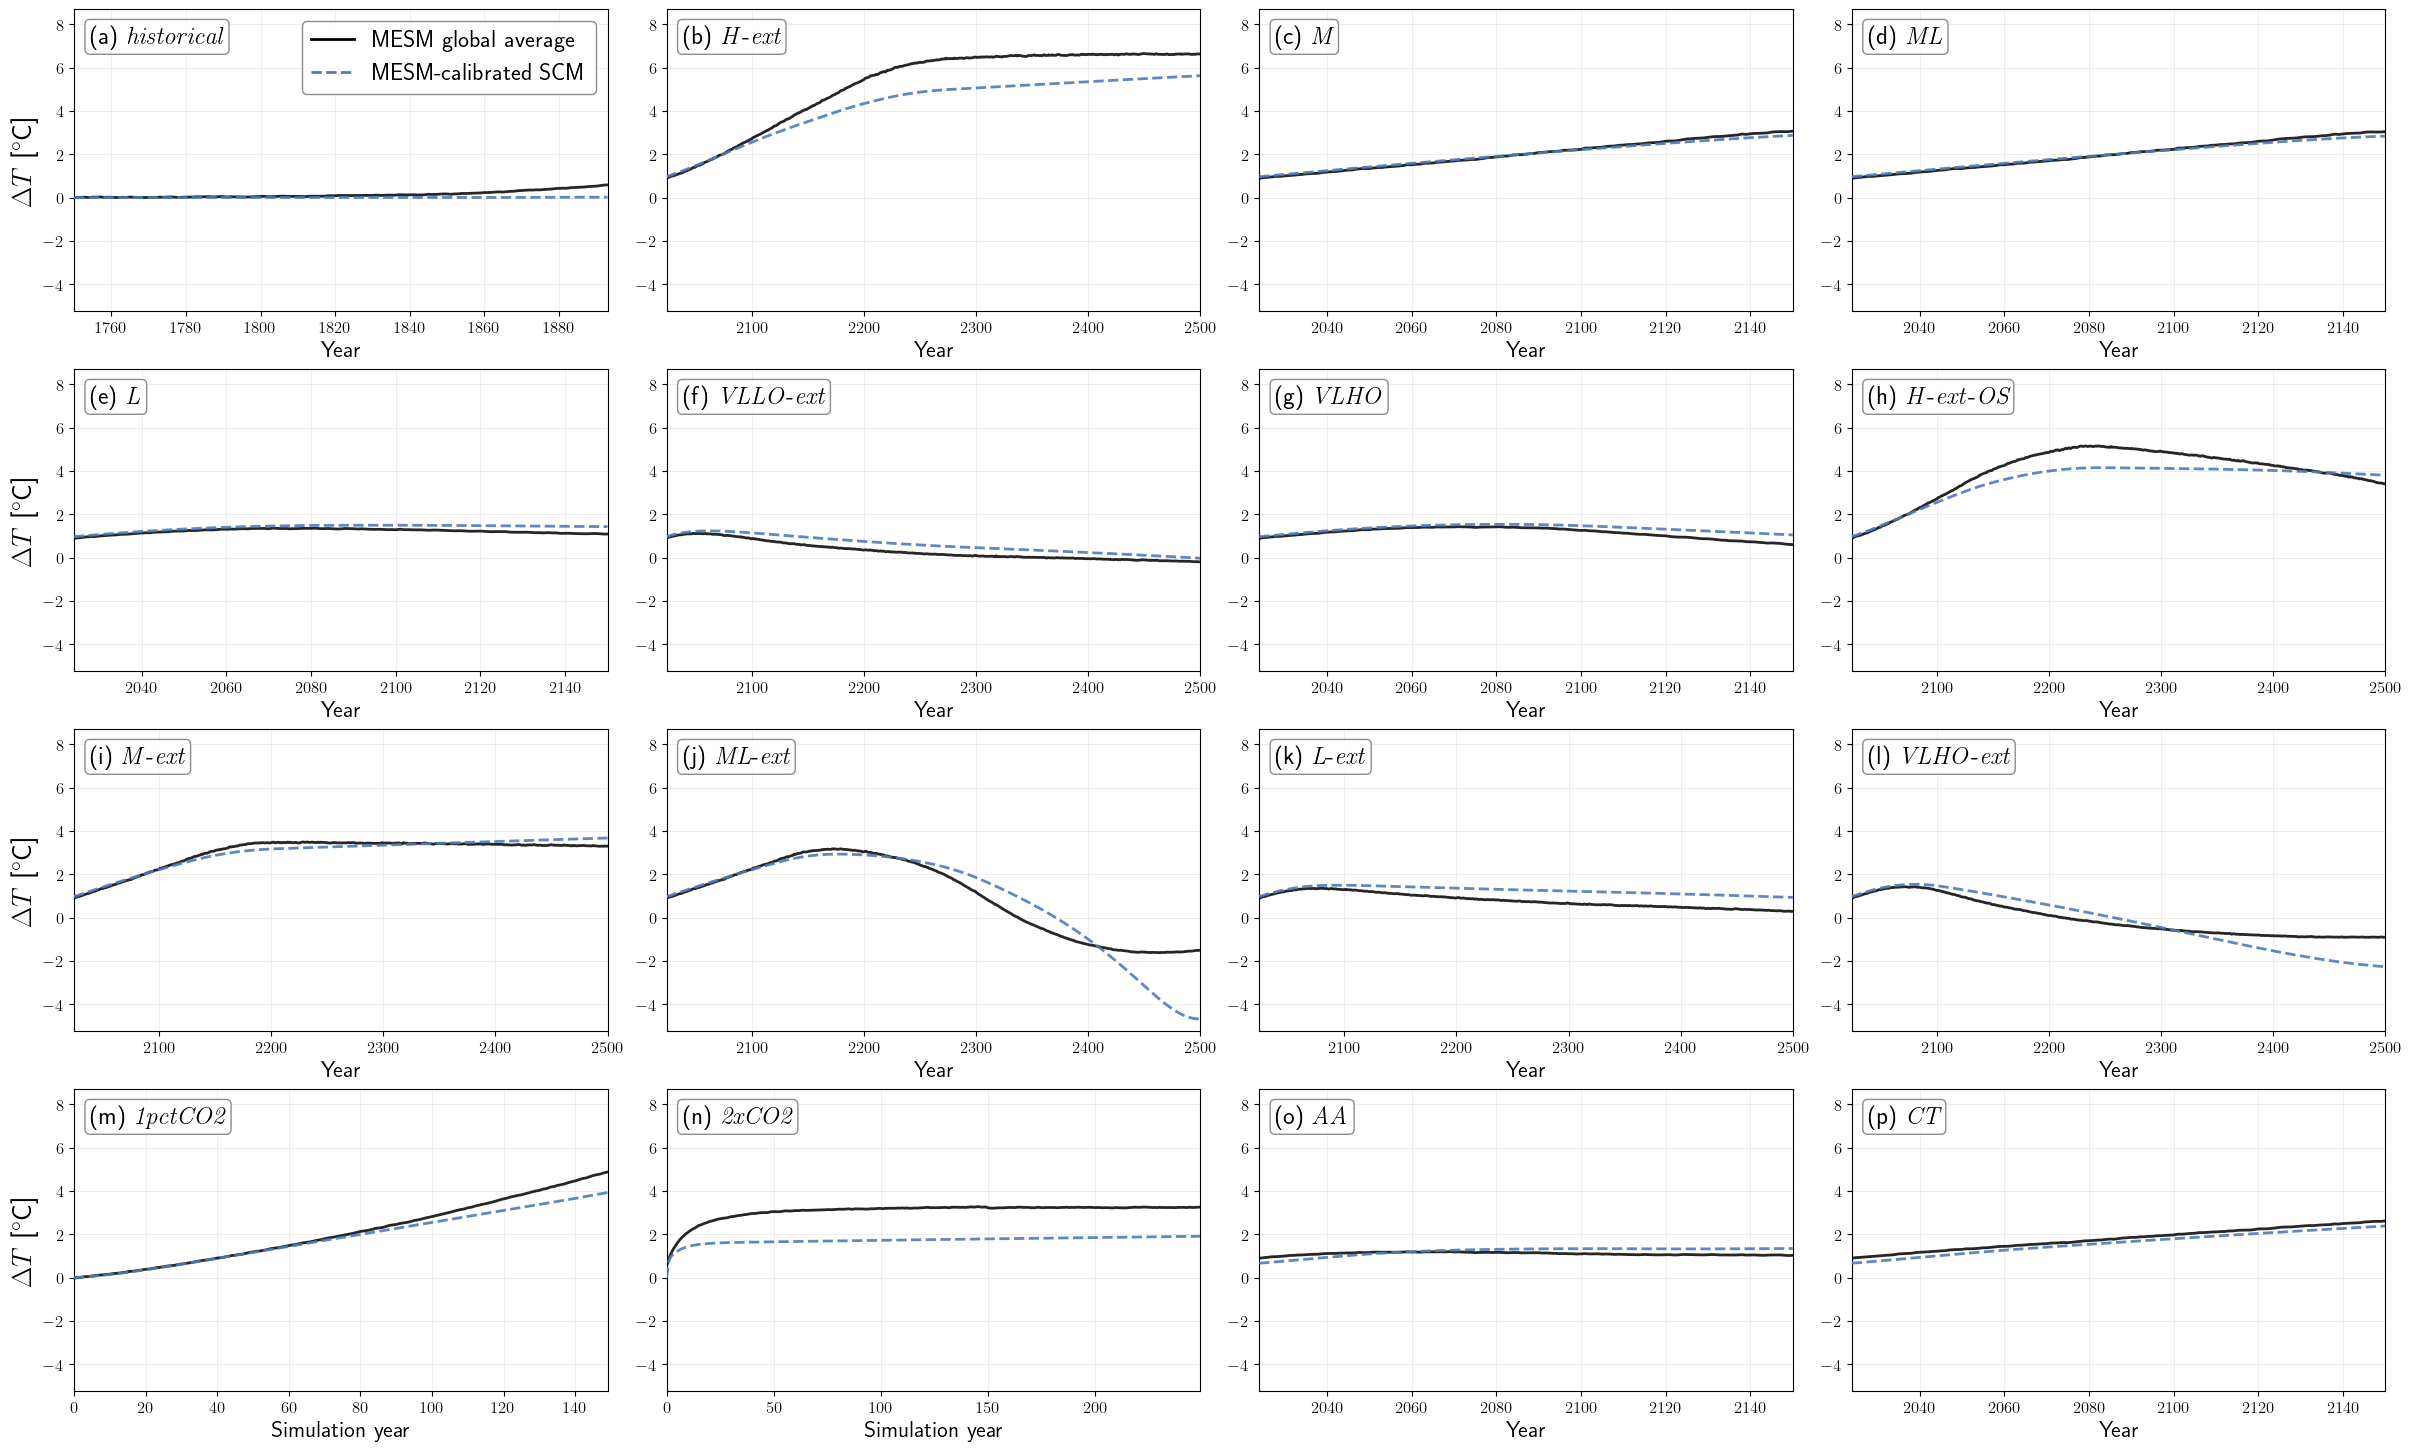

In [29]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_tier1_v2_diag, ncols=4, save="fig_scm_mesm_fidelity_grid_tier1_2xco2carbon",
)

### Final carbon-cycle comparison

In [30]:
a_v2, tau_v2 = np.asarray(_p1b['a']), np.asarray(_p1b['tau'])
o_v2 = np.argsort(tau_v2)
print("Carbon-cycle pools: Phase 1 (1pctCO2 only) vs Phase 1b (+2xCO2 pulse):")
print(f"  Phase 1   a = {np.round(a1[o1], 3)}   tau (yr) = {np.round(tau1[o1], 2)}")
print(f"  Phase 1b  a = {np.round(a_v2[o_v2], 3)}   tau (yr) = {np.round(tau_v2[o_v2], 2)}")

frac1  = a1[np.argmin(tau1)]
frac_v2 = a_v2[np.argmin(tau_v2)]
print(f"\n  fastest-pool fraction: {frac1*100:.0f}% (Phase 1, tau={tau1[np.argmin(tau1)]:.2f} yr) "
      f"-> {frac_v2*100:.0f}% (Phase 1b, tau={tau_v2[np.argmin(tau_v2)]:.2f} yr)")
print(f"\n  Cost: 1pctCO2's in-sample fit (see Phase 1b cell above) is no longer as tight "
      f"as Phase 1's ramp-only fit -- the two experiments pull the pool partition in "
      f"different directions, and a 4-pool linear carbon cycle cannot fully reconcile "
      f"both a smooth ramp and a sharp pulse simultaneously. The skill table above "
      f"reports whether that trade nets out positive once it propagates through the "
      f"re-chained thermal fit and the full scenario suite.")

Carbon-cycle pools: Phase 1 (1pctCO2 only) vs Phase 1b (+2xCO2 pulse):
  Phase 1   a = [0.78  0.129 0.049 0.041]   tau (yr) = [8.8000000e-01 7.8099999e+00 1.2308000e+02 2.5120505e+05]
  Phase 1b  a = [0.213 0.103 0.069 0.615]   tau (yr) = [8.2999998e-01 2.0450001e+01 1.9039200e+03 1.3925604e+07]

  fastest-pool fraction: 78% (Phase 1, tau=0.88 yr) -> 21% (Phase 1b, tau=0.83 yr)

  Cost: 1pctCO2's in-sample fit (see Phase 1b cell above) is no longer as tight as Phase 1's ramp-only fit -- the two experiments pull the pool partition in different directions, and a 4-pool linear carbon cycle cannot fully reconcile both a smooth ramp and a sharp pulse simultaneously. The skill table above reports whether that trade nets out positive once it propagates through the re-chained thermal fit and the full scenario suite.
